# Edges

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...


============|Starting random seed 1|============
============|Acceleration is 10.0|============
UNIVERSAL
Universal fidelity is 0.006410102758686623
DEFAULT
    constructing UnitarySmoothPulseProblem...
	using integrator: DataType
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint

  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`



        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    97590
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     3560
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      712
                     variables with only upper bounds:        0
Total number of equality constraints.................:     3239
Total number of inequality constraints...............:        1
        inequality constraints with onl

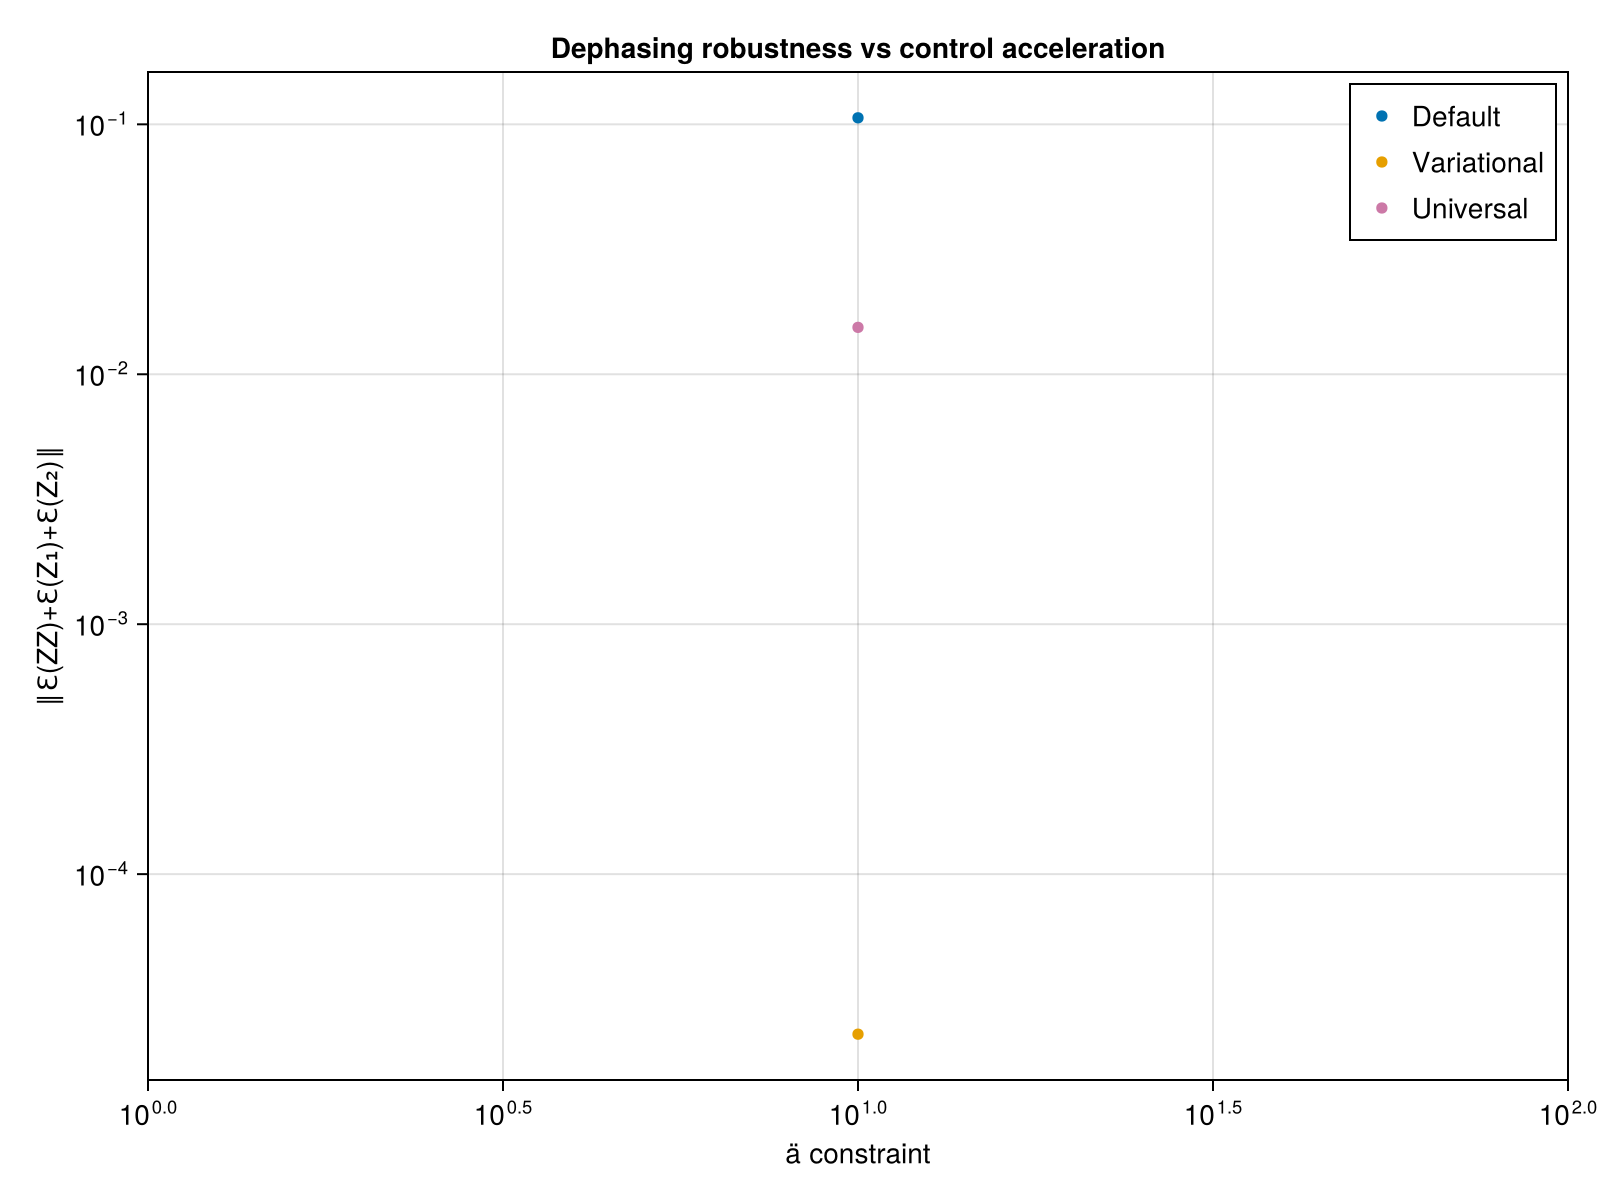

CairoMakie.Screen{IMAGE}


In [6]:
import Pkg; Pkg.activate(".."); Pkg.instantiate();
Pkg.develop(path="../../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
⊗ = kron;

# variational objective metric
function var_obj(
    traj::NamedTrajectory, 
    H_drift::Matrix{ComplexF64},
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    T = traj.T
    varsys = VariationalQuantumSystem(H_drift, H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, varsys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / ((T-1) * Δt)^2 / d
end

function scatter_with_line!(ax, x, y; color, label)
    lines!(ax, x, y; color=color, linewidth=2)         # connect points
    scatter!(ax, x, y; color=color, marker=:circle, 
                markersize=8, label=label)                 # overlay dots + legend
end

# Problem parameters
seed = 1
println("============|Starting random seed $seed|============")
var_avg_vec = [] # ZZ, Z1, Z2 average
def_avg_vec = []
uni_avg_vec = []

var_full_vec = []
def_full_vec = []
uni_full_vec = []

var_F = []
def_F = []
uni_F = []

#ä_vals = exp10.(range(-2, stop = 3, length = 10))
ä = 10.0
ä_vals = [ä]
F = 0.9999 # target fidelity
T = 80
Δt = 0.2
num_iter = 200
θ = pi / 10
iSWAP = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
V_dag = exp(1.0im * θ * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
U_goal = V_dag * iSWAP * V_dag
a_bound = 2.0 * pi # constrain to 10 MHz

println("============|Acceleration is $ä|============")

X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z
XX = GATES.X ⊗ GATES.X # transversal coupling
YY = GATES.Y ⊗ GATES.Y # transversal coupling
ZZ = GATES.Z ⊗ GATES.Z # transverse coupling, for error comparison
XY = GATES.X ⊗ GATES.Y
YX = GATES.Y ⊗ GATES.X
XZ = GATES.X ⊗ GATES.Z
ZX = GATES.Z ⊗ GATES.X
YZ = GATES.Y ⊗ GATES.Z
ZY = GATES.Z ⊗ GATES.Y

pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ]

H_drive = [X1, Y1, X2, Y2] # single qubit controls + tunable coupling
H_drift = 2 * pi * 0.01 * (XX + YY)
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drift, H_drive)
# Universal 
println("UNIVERSAL")
Random.seed!(seed)
uni_prob = UnitaryUniversalProblem(
    sys, U_goal, T, Δt, Δt_max=20. * Δt, Δt_min=0.5 * Δt, a_bound = a_bound, dda_bound=ä;
    activate_hyperspeed=true,
    Q=0.0,
    Q_t=1.0,
    piccolo_options=piccolo_opts
    )
push!(uni_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, uni_prob.trajectory))
#solve!(uni_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(uni_prob, max_iter=50, print_level=5)
F_uni = unitary_rollout_fidelity(uni_prob.trajectory, sys)
println("Universal fidelity is $F_uni")
push!(uni_F, F_uni)

# Default
println("DEFAULT")
Random.seed!(seed)
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; Δt_max=4.2 * Δt, Δt_min=.5 * Δt, 
                                a_bound = a_bound, dda_bound=ä, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(def, max_iter=50, print_level=5)
F_def = unitary_rollout_fidelity(def.trajectory, sys)
println("Default fidelity is $F_def")
push!(def_F, F_def)

∂ₑHₐ = [Z1, Z2, ZZ];

varsys_add = VariationalQuantumSystem(
    H_drift,
    H_drive,
    ∂ₑHₐ
)

var_count = length(∂ₑHₐ)

Random.seed!(seed)
println("VARIATIONAL")
var_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for i in 1:var_count],
    Δt_max = 4.2 * Δt,
    Δt_min = 1.0 * Δt,
    a_bound = a_bound,
    dda_bound = ä,
    Q=0.0,
    Q_r = 10.0,
    Q_s = 0.0,
    Q_t = 0.00,
    piccolo_options = PiccoloOptions(verbose=false)
)
push!(var_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory))
solve!(var_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
F_var = unitary_rollout_fidelity(var_prob.trajectory, sys)
println("Variational fidelity is $F_var")
push!(var_F, F_var)

var_susc = []
for P in pauli_strings
    push!(var_susc, var_obj(var_prob.trajectory, H_drift, H_drive, [P]))
end
push!(var_full_vec, var_susc)

def_susc = []
for P in pauli_strings
    push!(def_susc, var_obj(def.trajectory, H_drift, H_drive, [P]))
end
push!(def_full_vec, def_susc)

uni_susc = []
for P in pauli_strings
    push!(uni_susc, var_obj(uni_prob.trajectory, H_drift, H_drive, [P]))
end
push!(uni_full_vec, uni_susc)

var_zz = var_obj(var_prob.trajectory, H_drift, H_drive, [ZZ])
var_z1 = var_obj(var_prob.trajectory, H_drift, H_drive, [Z1])
var_z2 = var_obj(var_prob.trajectory, H_drift, H_drive, [Z2])
var_avg = (var_zz + var_z1 + var_z2) / 3
push!(var_avg_vec, var_avg)

def_zz = var_obj(def.trajectory, H_drift, H_drive, [ZZ])
def_z1 = var_obj(def.trajectory, H_drift, H_drive, [Z1])
def_z2 = var_obj(def.trajectory, H_drift, H_drive, [Z2])
def_avg = (def_zz + def_z1 + def_z2) / 3
push!(def_avg_vec, def_avg)

uni_zz = var_obj(uni_prob.trajectory, H_drift, H_drive, [ZZ])
uni_z1 = var_obj(uni_prob.trajectory, H_drift, H_drive, [Z1])
uni_z2 = var_obj(uni_prob.trajectory, H_drift, H_drive, [Z2])
uni_avg = (uni_zz + uni_z1 + uni_z2) / 3
push!(uni_avg_vec, uni_avg)



fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1];
xlabel = "ä constraint",
ylabel = "‖Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)‖",
xscale = log10,
yscale = log10,
title  = "Dephasing robustness vs control acceleration",
)

colors = Makie.wong_colors()

scatter_with_line!(ax, ä_vals, def_avg_vec; color=colors[1], label="Default")
scatter_with_line!(ax, ä_vals, var_avg_vec; color=colors[2], label="Variational")
scatter_with_line!(ax, ä_vals, uni_avg_vec; color=colors[4], label="Universal")

axislegend(ax; position = :rt)

using DataFrames, CSV

df = DataFrame(
ä_vals = ä_vals,
def_avg_vec = def_avg_vec,
uni_avg_vec = uni_avg_vec,
var_avg_vec = var_avg_vec,
def_F = def_F,
var_F = var_F,
uni_F = uni_F,
var_full_vec = var_full_vec,
def_full_vec = def_full_vec,
uni_full_vec = uni_full_vec,
)

CSV.write("dda_constraint_iswap_T50_seed_$seed.csv", df)
save("dda_constraint_iswap_T50_seed_$seed.png", fig)
display(fig)

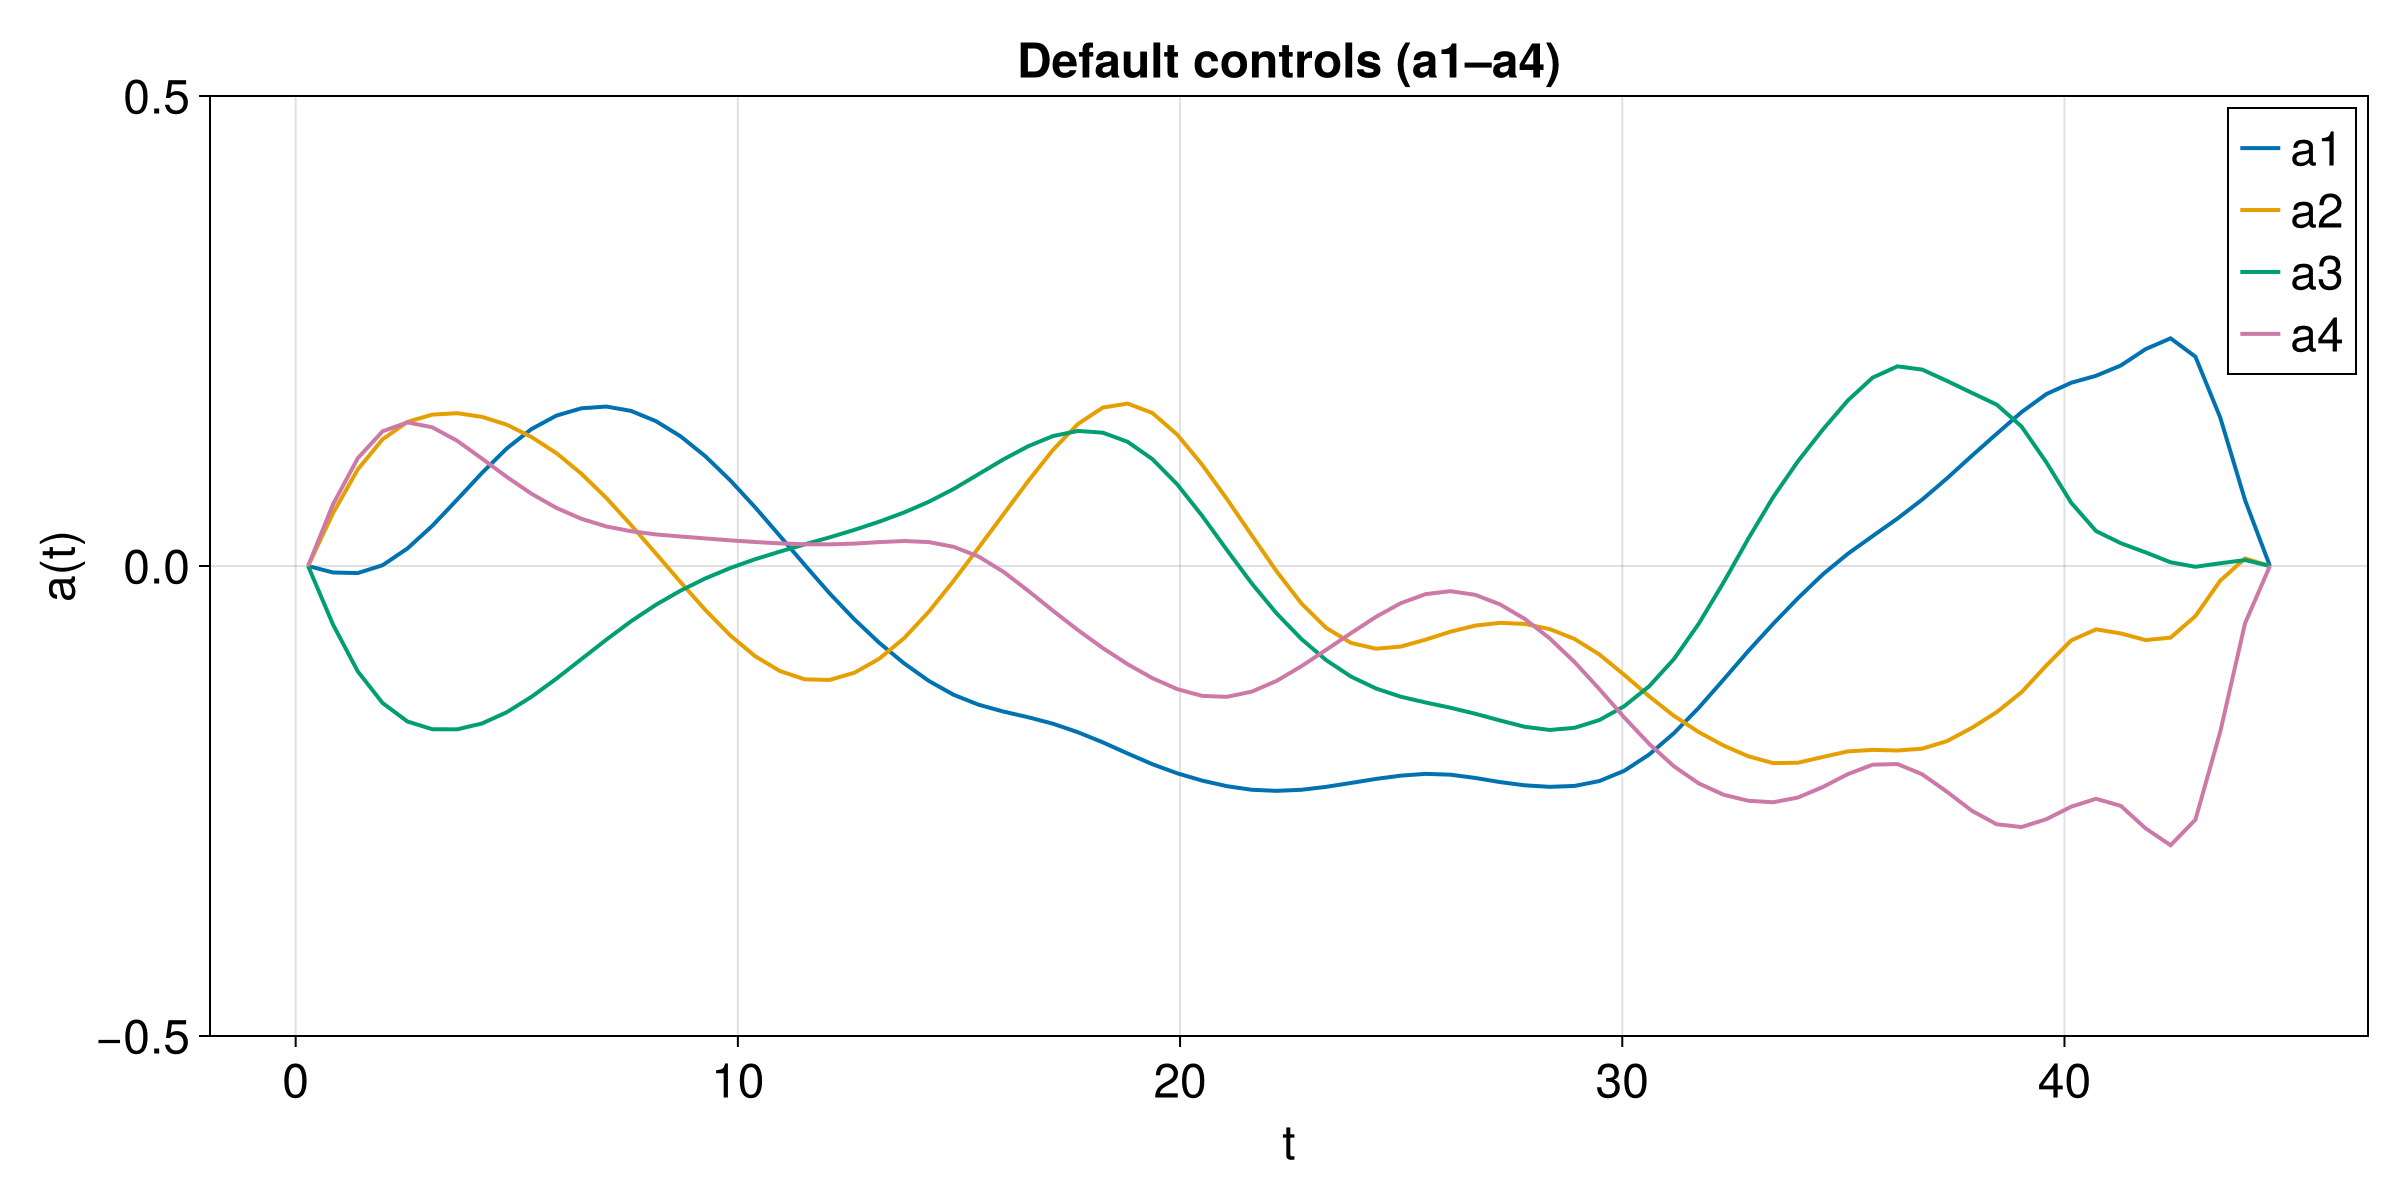

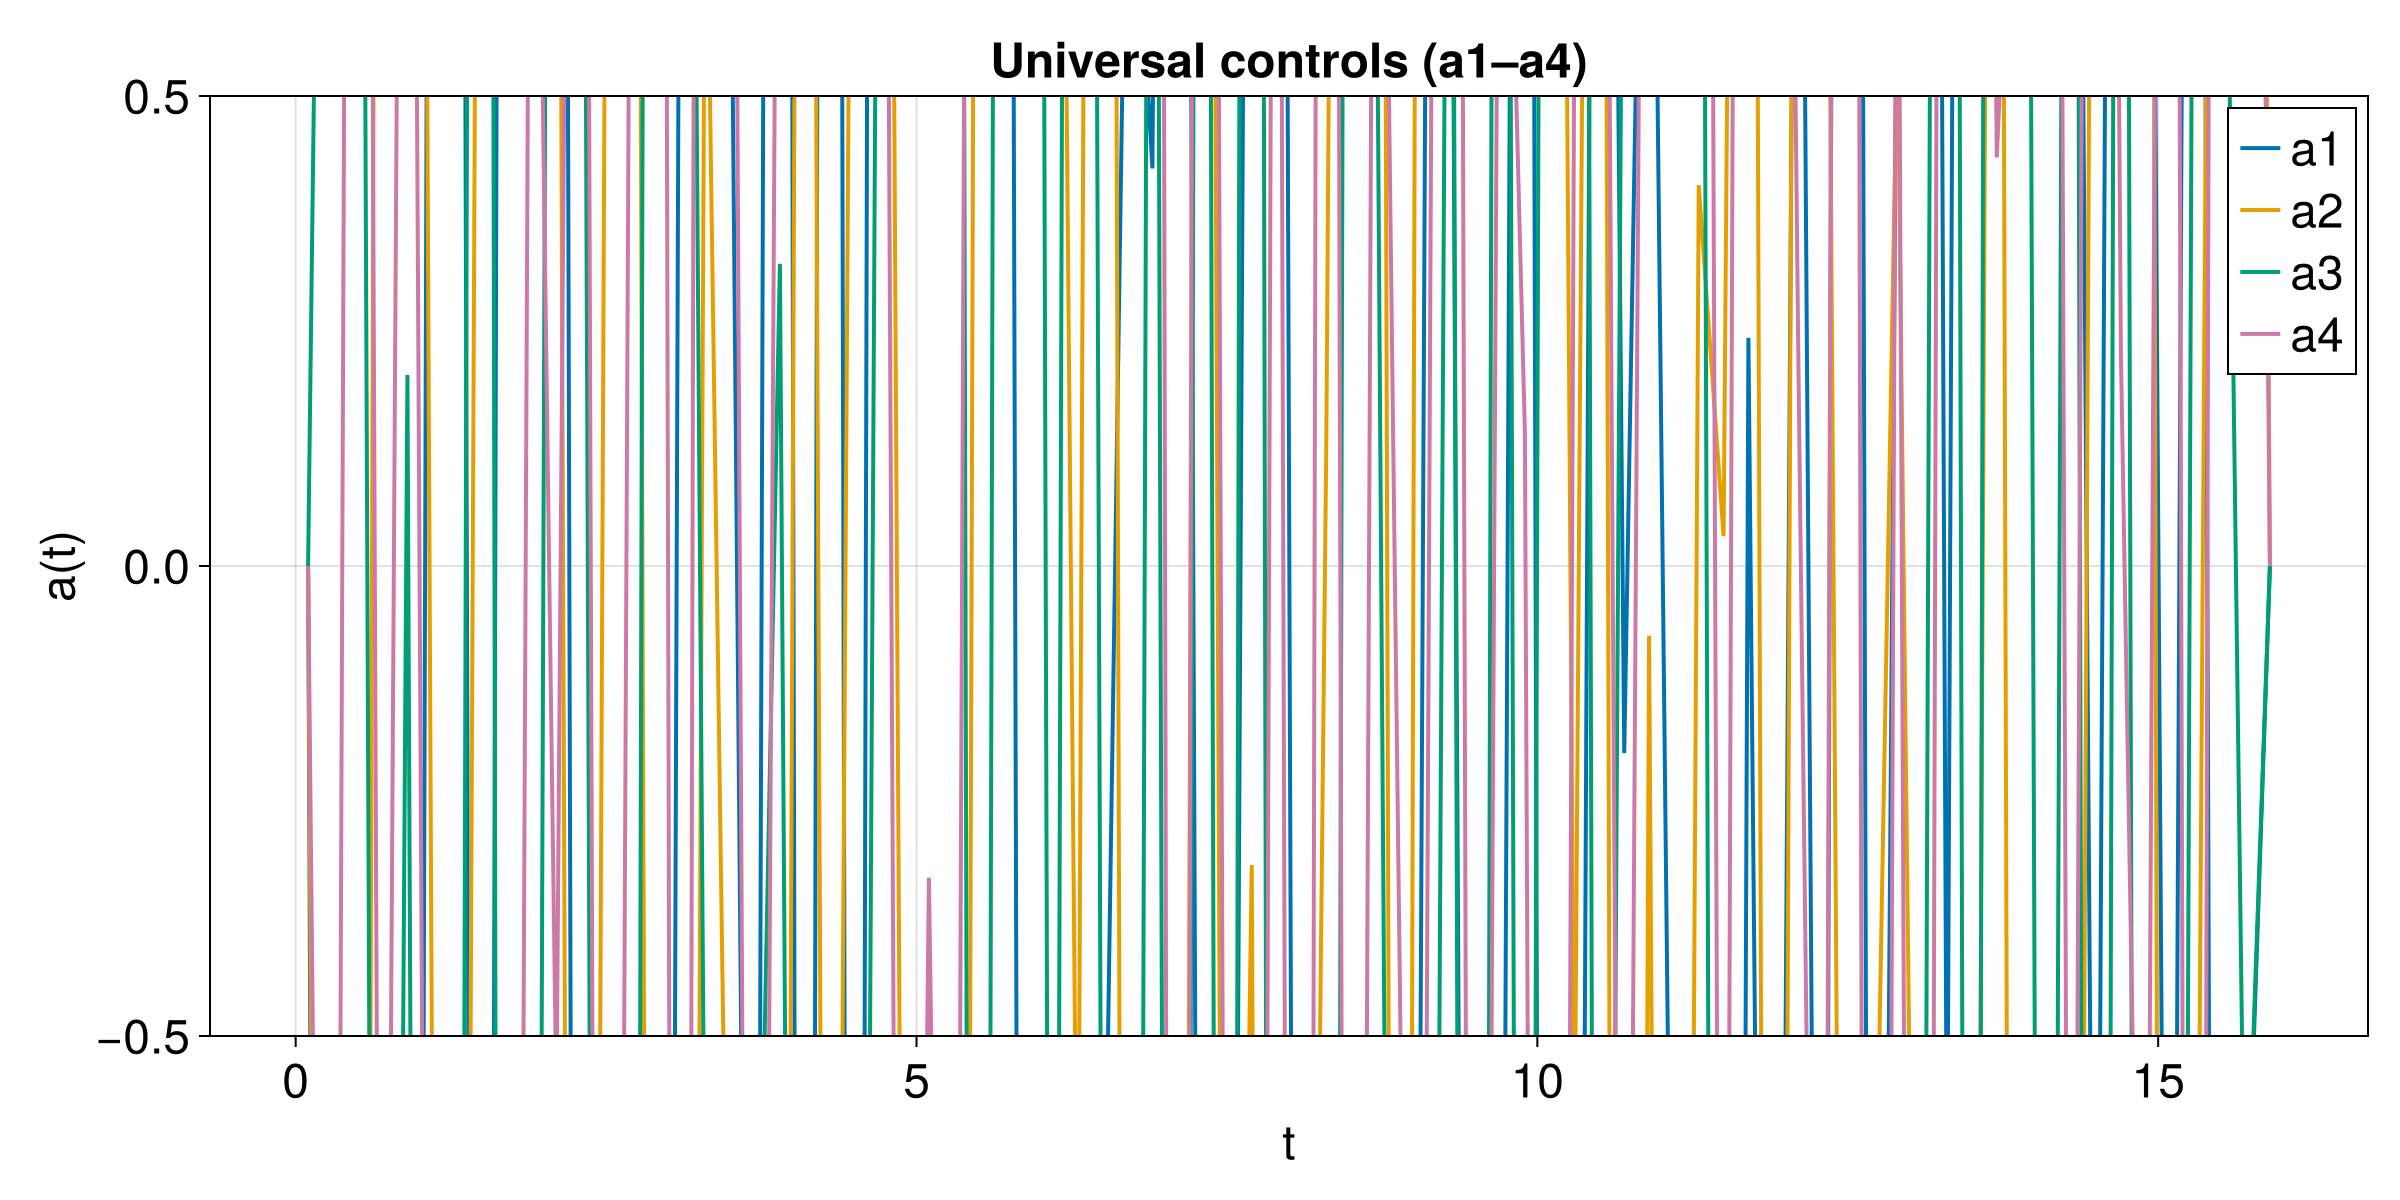

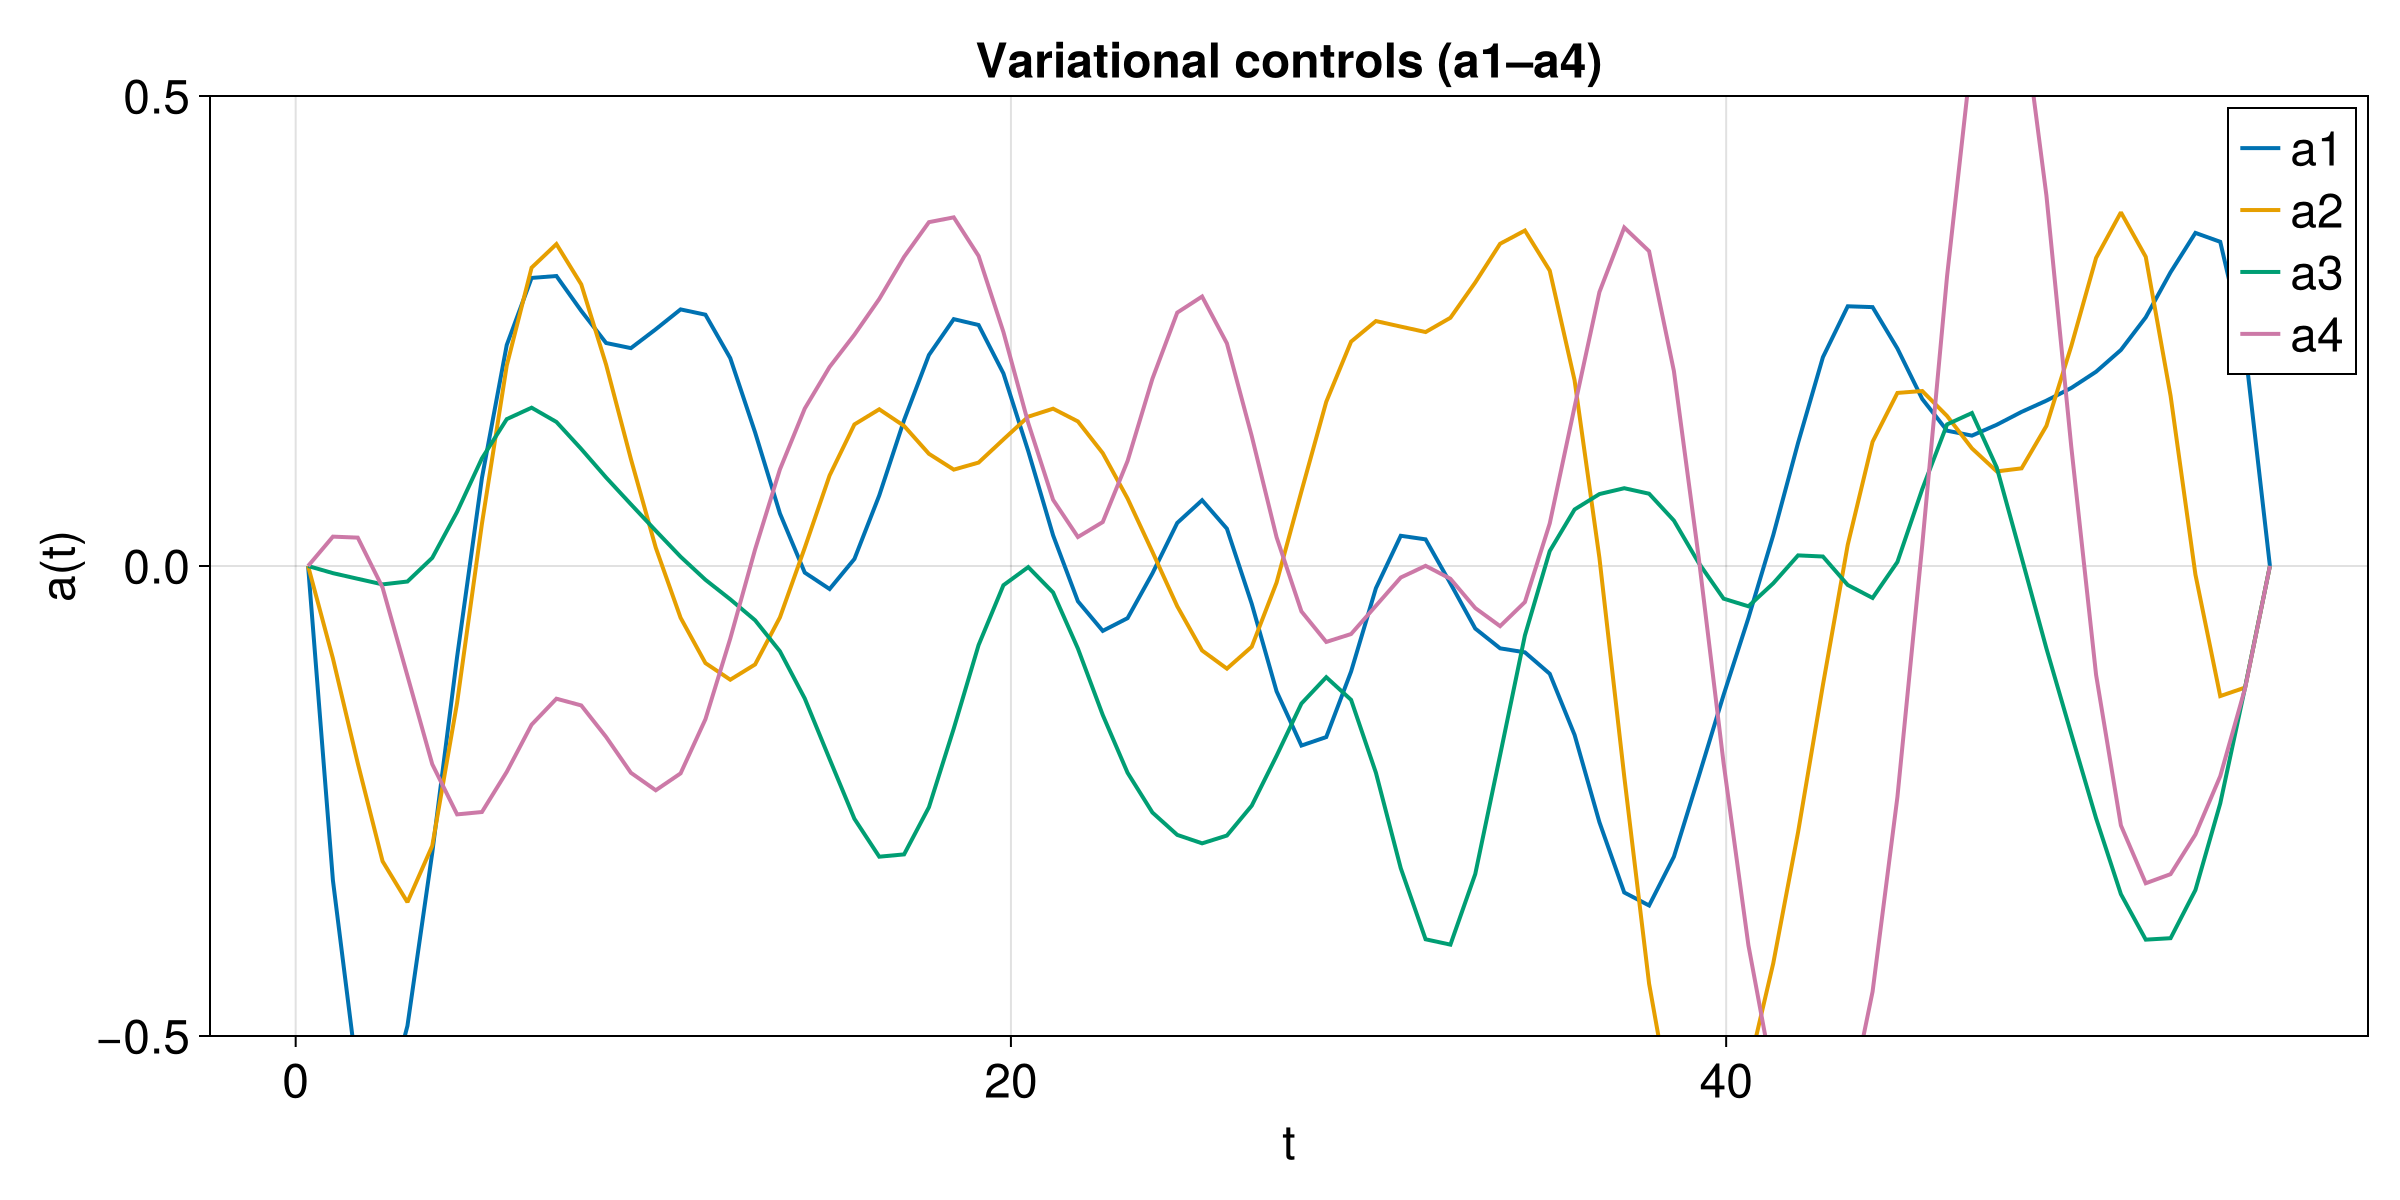

In [7]:


# %% Plot a1–a4 on ONE axis (overlaid) for each solution, with y-lims [-1, 1]

using CairoMakie

problems = [
    (def,      "Default"),
    (uni_prob, "Universal"),
    (var_prob, "Variational"),
]

# --- robust get ---
function traj_get(traj, sym::Symbol)
    try
        return traj[sym]
    catch
        return getproperty(traj, sym)
    end
end

# --- Δt as 1D vector ---
dt_vector(traj) = vec(collect(traj_get(traj, :Δt)))

# --- time axis for interval-defined controls ---
function control_time_axis(traj, n::Int)
    Δt = dt_vector(traj)
    t_nodes = cumsum(vcat(0.0, Δt))
    t_mid   = (t_nodes[1:end-1] .+ t_nodes[2:end]) ./ 2

    if length(t_mid) == n
        return t_mid
    elseif length(t_nodes) == n
        return t_nodes
    else
        return collect(range(0.0, 1.0; length=n))
    end
end

# --- ensure A is (Ntime, Nctrl) ---
function a_matrix(traj)
    Araw = traj_get(traj, :a)
    A = ndims(Araw) == 1 ? reshape(collect(Araw), :, 1) : Matrix(Araw)

    # if likely (Nctrl, Ntime) -> transpose
    if size(A, 1) ≤ 10 && size(A, 2) > size(A, 1)
        A = A'
    end
    return A
end

function plot_a1_to_a4_overlay(traj; title="", ylims_tuple=(-1.0, 1.0))
    @assert :a in traj.names "traj does not contain :a"

    A = a_matrix(traj)
    ntime, nctrl = size(A)
    @assert nctrl ≥ 4 "Expected at least 4 controls in :a, got $nctrl"

    t = control_time_axis(traj, ntime)

    fig = Figure(fontsize=24, size=(1200, 600))
    ax = Axis(fig[1, 1], title=title, xlabel="t", ylabel="a(t)")

    for j in 1:4
        lines!(ax, t, A[:, j], linewidth=2, label="a$j")
    end

    ylims!(ax, ylims_tuple[1], ylims_tuple[2])
    axislegend(ax; position=:rt)

    return fig
end

for (prob, label) in problems
    fig = plot_a1_to_a4_overlay(prob.trajectory; title="$label controls (a1–a4)", ylims_tuple=(-0.5, 0.5))
    display(fig)
end

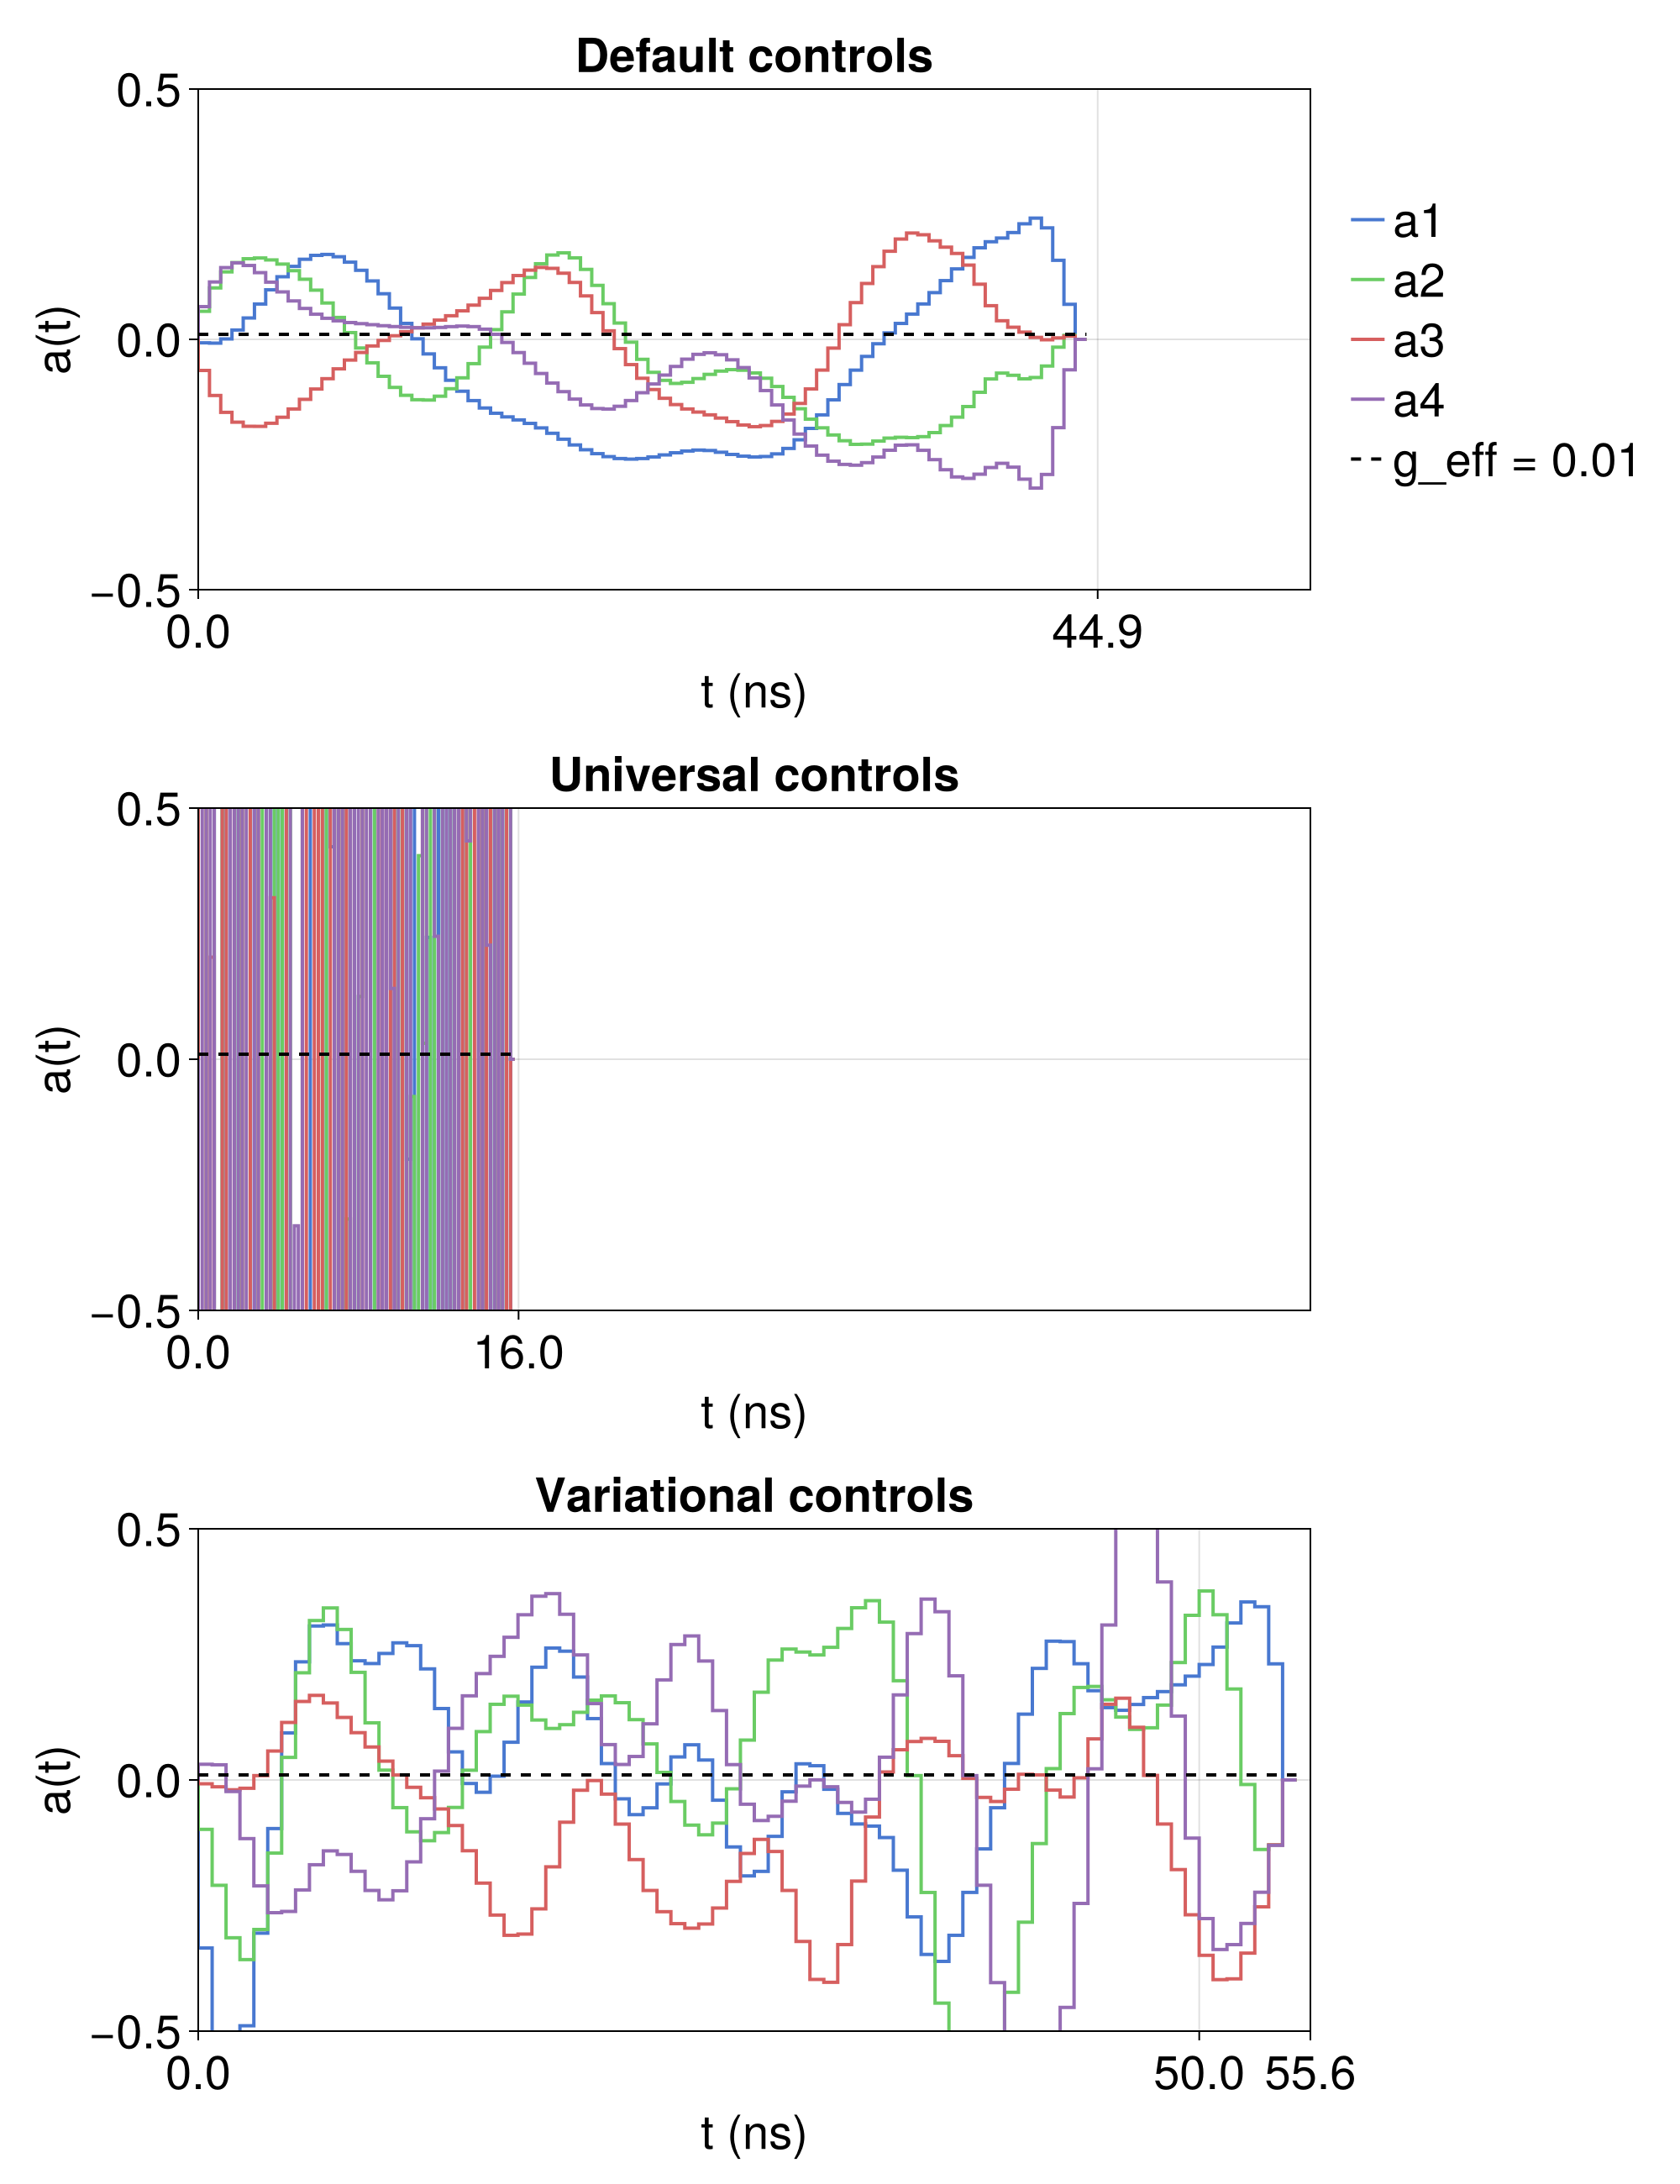

CairoMakie.Screen{IMAGE}


In [8]:
# %% ONE FIGURE: 3 stacked subplots (Default / Universal / Variational)
#    Plot :a as true PWC on t_nodes (no artificial padding/shift)
#    seaborn muted colors + xticks every 50 ns
#    dashed g_eff starts at t=0 and ends at the end of the last "microwaves on" interval
#
#    Font sizes matched to your fidelity-curve plot:
#      Figure(fontsize=28, size=(1000, 1000))  (scaled taller for 3 rows)
#      Axis titles/labels default to fig fontsize unless overridden

using CairoMakie
using ColorSchemes

problems = [
    (def,      "Default"),
    (uni_prob, "Universal"),
    (var_prob, "Variational"),
]

# seaborn muted palette (first 4)
cols = ColorSchemes.seaborn_muted6.colors
a_colors = (cols[1], cols[2], cols[3], cols[4])

# --- robust get ---
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

# --- Δt as 1D vector (ns) ---
dt_vector(traj) = vec(collect(traj_get(traj, :Δt)))

# --- ensure :a is (Ntime, Nctrl) ---
function a_matrix(traj)
    Araw = traj_get(traj, :a)
    A = ndims(Araw) == 1 ? reshape(collect(Araw), :, 1) : Matrix(Araw)
    if size(A, 1) ≤ 10 && size(A, 2) > size(A, 1)
        A = A'
    end
    return A
end

# --- node times from Δt (ns) ---
time_nodes_ns(traj) = cumsum(vcat(0.0, Float64.(dt_vector(traj))))  # length Ndt+1

function as_interval_values(u::AbstractVector{<:Real}, Ndt::Int)
    u = Float64.(u)
    if length(u) == Ndt
        return u
    elseif length(u) == Ndt + 1
        return u[1:end-1]
    else
        error("Control length $(length(u)) incompatible with Ndt=$Ndt")
    end
end

intervals_to_stairs_y(v::AbstractVector{<:Real}) = vcat(Float64.(v), NaN)

function plot_panel!(ax, traj;
    title_str::String,
    ylims_tuple=(-0.5, 0.5),
    xtick_step=50.0,
    g_eff=0.01,
    on_tol=1e-6,
    show_legend_labels::Bool=true
)
    A = a_matrix(traj)
    _, nctrl = size(A)
    @assert nctrl ≥ 4 "Expected at least 4 controls in :a, got $nctrl"

    dt_ns = Float64.(dt_vector(traj))
    Ndt = length(dt_ns)
    t_nodes = time_nodes_ns(traj)
    @assert length(t_nodes) == Ndt + 1

    ax.title  = title_str
    ax.xlabel = "t (ns)"
    ax.ylabel = "a(t)"

    # Build interval values for a1..a4, plot as PWC stairs
    v_list = Vector{Vector{Float64}}(undef, 4)
    for j in 1:4
        v = as_interval_values(A[:, j], Ndt)
        v_list[j] = v
        y = intervals_to_stairs_y(v)
        stairs!(ax, t_nodes, y; linewidth=2, color=a_colors[j],
                label = show_legend_labels ? "a$j" : "")
    end

    # Determine microwave-on intervals from the plotted PWC values
    active = falses(Ndt)
    for i in 1:Ndt
        active[i] = maximum(abs.((v_list[1][i], v_list[2][i], v_list[3][i], v_list[4][i]))) > on_tol
    end

    # dashed g_eff: start at t=0, end at end of last active interval
    if any(active)
        i2 = findlast(active)
        t_end = t_nodes[i2 + 1]
        lines!(ax, [0.0, t_end], [g_eff, g_eff];
            linestyle=:dash, linewidth=2, color=:black,
            label = show_legend_labels ? "g_eff = $(g_eff)" : ""
        )
    end

    ylims!(ax, ylims_tuple...)

    # xticks every 50 ns; include endpoint tick
    xmax = t_nodes[end]
    ticks = collect(0.0:xtick_step:(floor(xmax/xtick_step)*xtick_step))
    isempty(ticks) && (ticks = [0.0])
    if abs(ticks[end] - xmax) > 1e-9
        ticks = vcat(ticks, xmax)
    end
    ax.xticks = (ticks, string.(round.(ticks, digits=1)))

    return xmax
end

# Match your other figure: fontsize=28.
# Keep width 1000; height scaled to 3 rows (≈1000 * 3 / 1) but a bit tighter.
fig = Figure(fontsize=28, size=(1000, 1300))

axes = [
    Axis(fig[1, 1]),
    Axis(fig[2, 1]),
    Axis(fig[3, 1]),
]

Tpulses = Float64[]
for (k, ((prob, label), ax)) in enumerate(zip(problems, axes))
    Tpulse = plot_panel!(ax, prob.trajectory;
        title_str = "$label controls",
        ylims_tuple = (-0.5, 0.5),
        xtick_step = 50.0,
        g_eff = 0.01,
        on_tol = 1e-6,
        show_legend_labels = (k == 1),
    )
    push!(Tpulses, Tpulse)
end

# unify x-limits across panels
Tmax = maximum(Tpulses)
for ax in axes
    xlims!(ax, 0, Tmax)
end

Legend(fig[1, 2], axes[1]; framevisible=false)

display(fig)

In [9]:

mkpath("figures")  # creates "figures/" if it doesn't exist

save(joinpath("figures", "controls_pwc.png"), fig; px_per_unit = 5)  # PNG

In [10]:
def.trajectory.a[1,:]

80-element Vector{Float64}:
  0.0
 -0.006893604392188085
 -0.007539251269163457
  0.000845475374253119
  0.018630360560726374
  0.04271248119734094
  0.07057116308629253
  0.09896610357645712
  0.12506505924056494
  0.1457748151354982
  ⋮
  0.1949743069592852
  0.20238009941416643
  0.21335837520796527
  0.23081432727365622
  0.24218903270476413
  0.22269130779934287
  0.15791883508244506
  0.07001397001905951
  0.0

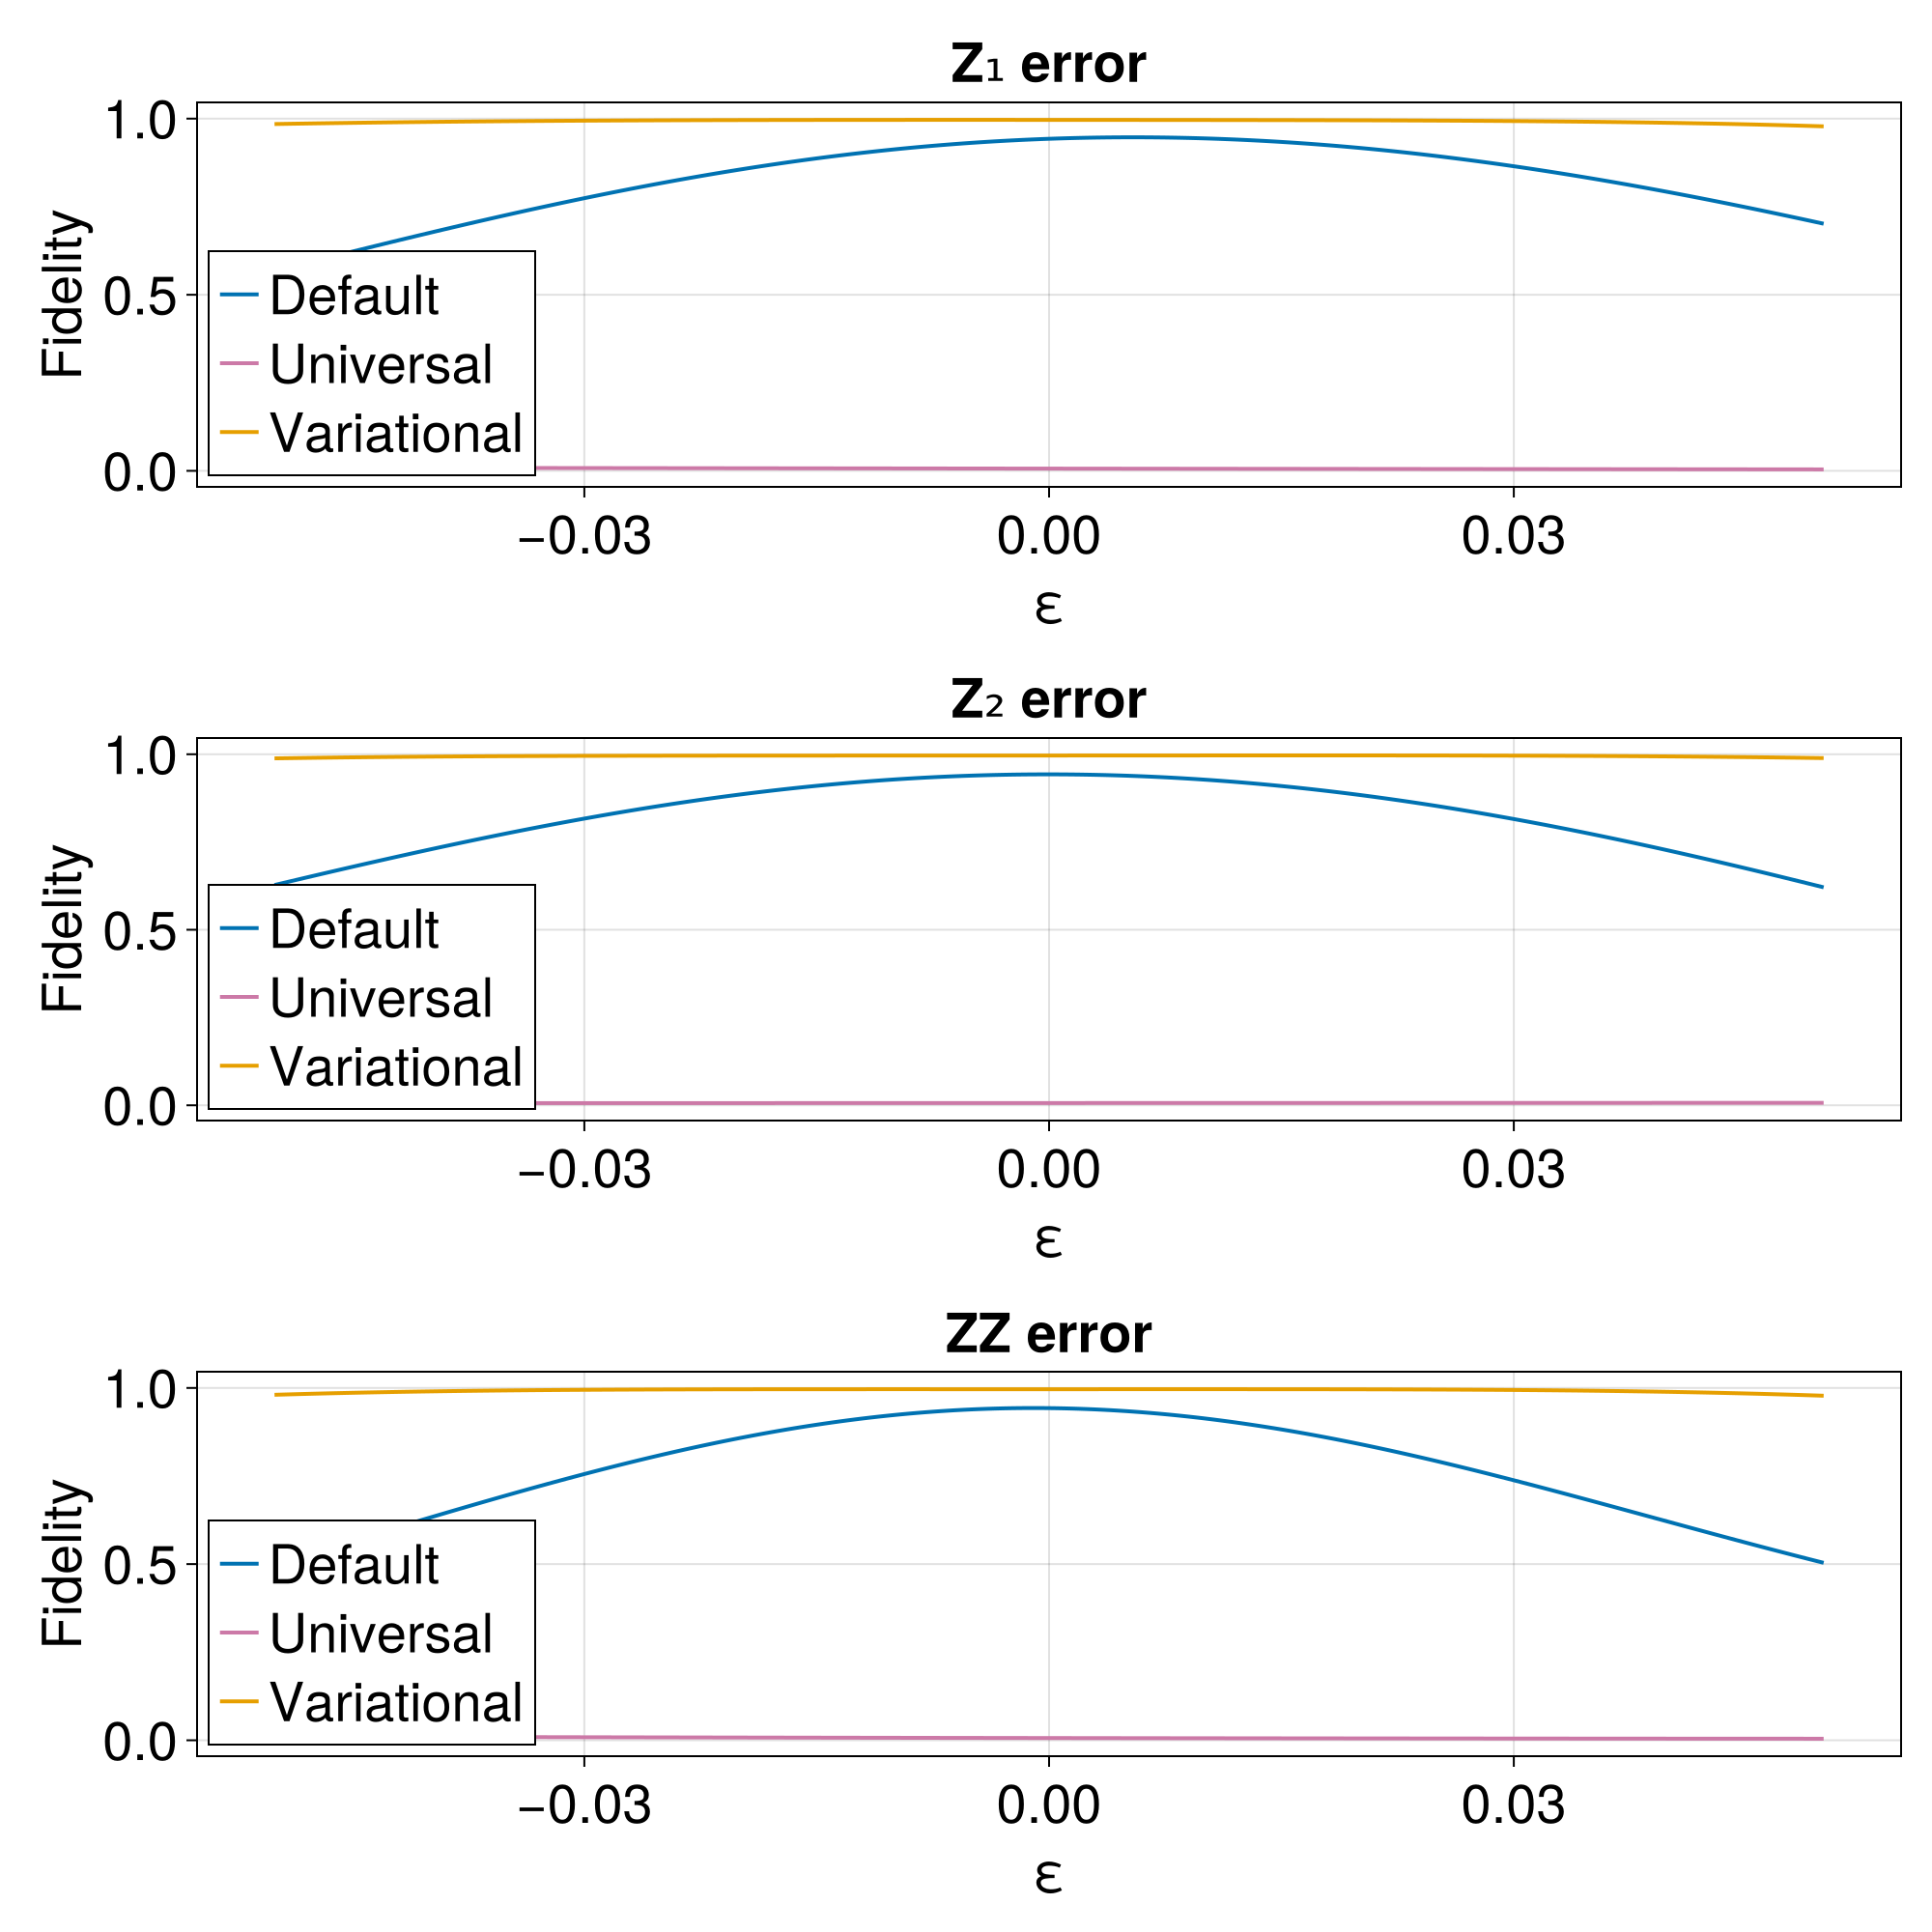

CairoMakie.Screen{IMAGE}


In [11]:

# %% Cell 2 — fidelity curves vs Z1, Z2, ZZ error strength (CORRECT drift addition)

using CairoMakie
⊗ = kron

# --- Build error operators using SAME basis as optimization (GATES.*) ---
Z1_err = GATES.Z ⊗ GATES.I
Z2_err = GATES.I ⊗ GATES.Z
ZZ_err = GATES.Z ⊗ GATES.Z

errors = [
    (Z1_err, "Z₁"),
    (Z2_err, "Z₂"),
    (ZZ_err, "ZZ"),
]

# --- Use the SAME control Hamiltonians and drift as optimization ---
# assumes these exist from your solve cell:
#   H_drive :: Vector{Matrix{ComplexF64}}
#   H_drift :: Matrix{ComplexF64}

problems = [
    (def,      "Default"),
    (uni_prob, "Universal"),
    (var_prob, "Variational"),
]

εs = collect(-0.05:0.0005:0.05)

# Sweep: drift + ε*error, with the same controls
fidelity_curve(prob, H_err) = [
    unitary_rollout_fidelity(prob.trajectory, QuantumSystem(H_drift + ε * H_err, H_drive))
    for ε in εs
]

colors = Makie.wong_colors()
colors = [colors[1], colors[4], colors[2]]
f = Figure(fontsize=28, size=(1000, 1000))

for (row, (H_err, label_err)) in enumerate(errors)
    ax = Axis(f[row, 1],
        title  = "$label_err error",
        xlabel = "ε",
        ylabel = "Fidelity",
    )

    for (i, (prob, label_prob)) in enumerate(problems)
        ys = fidelity_curve(prob, H_err)
        lines!(ax, εs, ys; label=label_prob, color=colors[i], linewidth=2)
    end

    axislegend(ax; position=:lb)
end

display(f)



In [ ]:
using FFTW
using LinearAlgebra
using CairoMakie

# ----------------------------
# USER KNOBS (your timing spec)
# ----------------------------
off_before_ns = 5.0      # everything OFF initially
geff_lead_ns  = 5.0      # g_eff ON before microwaves
geff_trail_ns = 5.0      # g_eff ON after microwaves
off_after_ns  = 5.0      # everything OFF at the end

g0 = 2π * 0.01           # coefficient multiplying (XX+YY)

M = 20                   # upsample factor
B3dB_Hz = 250e6          # Gaussian -3 dB BW
on_tol = 1e-6            # microwave-on detection in Piccolo


# ============================================================
# Helpers: pull Piccolo controls consistently
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    # if stored as 4×Ndt -> transpose to Ndt×4
    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end

    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))  # Ndt+1
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)

    tμ_start = t_nodes[i1]
    tμ_end   = t_nodes[i2 + 1]
    return tμ_start, tμ_end
end


# ============================================================
# Build UNIFORM dt signals on a clock where microwaves start at t = off_before + geff_lead
# ============================================================
function build_pwc_with_geff_leadlag(traj;
    off_before_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    off_after_ns::Float64,
    g0::Float64,
    M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)     # Ndt×4
    t_nodes0 = time_nodes_ns(traj)   # Ndt+1

    # detect microwave on-window in Piccolo's native clock
    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    # Shift Piccolo time so microwave start is at τ = 0 (internal microwave clock)
    t_nodes_shift = t_nodes0 .- tμ_start0

    # Choose uniform dt (FFT needs uniform)
    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / M

    # Define *experiment clock*:
    #   [0, off_before)               OFF
    #   [off_before, off_before+lead) g_eff ON only
    #   [tμ_exp_start, tμ_exp_end)    microwaves + g_eff ON
    #   [tμ_exp_end, tμ_exp_end+trail) g_eff ON only
    #   [end-off_after, end]          OFF
    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns

    T_end = g_end + off_after_ns

    t = collect(0.0:dt:T_end)

    # Evaluate Piccolo interval control at microwave-clock time τ (τ ∈ [0, Tμ))
    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        # τ in microwave clock, map to shifted t_nodes
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        # microwaves ON only in [tμ_exp_start, tμ_exp_end)
        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start  # microwave clock
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        # g_eff ON in [g_start, g_end)
        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, dt, Tμ, tμ_exp_start, tμ_exp_end, g_start, g_end, ux1, uy1, ux2, uy2, geff)
end


# ============================================================
# Gaussian filter ALL 5 channels (FFT lowpass)
# ============================================================
function fftfreq_hw(N::Int, dt_s::Float64)
    df = 1.0 / (N * dt_s)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_response(freqs, B3dB::Float64)
    σf = B3dB / sqrt(log(2.0))
    @. exp(-0.5 * (freqs^2) / σf^2)
end

function gaussian_filter_all5(sig; B3dB_Hz::Float64)
    dt_s = sig.dt * 1e-9
    N = length(sig.t)

    freqs = fftfreq_hw(N, dt_s)
    G = gaussian_response(freqs, B3dB_Hz)

    filt(x) = real.(ifft(G .* fft(x)))

    return (; t = sig.t,
        ux1 = filt(sig.ux1),
        uy1 = filt(sig.uy1),
        ux2 = filt(sig.ux2),
        uy2 = filt(sig.uy2),
        geff = filt(sig.geff),
    )
end


# ============================================================
# Plot microwaves + g_eff (PWC vs filtered)
# ============================================================
function plot_coeffs(sig_pwc, sig_filt; title_str="")
    t = sig_pwc.t

    fig = Figure(size=(1300, 900), fontsize=22)

    labels = ["ux1(t)", "uy1(t)", "ux2(t)", "uy2(t)", "g_eff(t)"]
    pwc_list = [sig_pwc.ux1, sig_pwc.uy1, sig_pwc.ux2, sig_pwc.uy2, sig_pwc.geff]
    flt_list = [sig_filt.ux1, sig_filt.uy1, sig_filt.ux2, sig_filt.uy2, sig_filt.geff]

    for r in 1:5
        ax = Axis(fig[r, 1],
            ylabel = labels[r],
            xlabel = (r == 5 ? "t (ns)" : ""),
            title  = (r == 1 ? title_str : ""),
        )

        # PWC (true applied coefficients)
        lines!(ax, t, pwc_list[r], linewidth=2, label="PWC")

        # Filtered (hardware-shaped)
        lines!(ax, t, flt_list[r], linewidth=2, alpha=0.55, label="Gaussian filtered")

        # Mark important boundaries
        vlines!(ax, [sig_pwc.g_start], linestyle=:dot, linewidth=1)        # g_eff on
        vlines!(ax, [sig_pwc.tμ_exp_start], linestyle=:dash, linewidth=1)  # microwaves on
        vlines!(ax, [sig_pwc.tμ_exp_end], linestyle=:dash, linewidth=1)    # microwaves off
        vlines!(ax, [sig_pwc.g_end], linestyle=:dot, linewidth=1)          # g_eff off

        hlines!(ax, [0.0], linestyle=:dot, linewidth=1)

        if r == 1
            axislegend(ax, position=:rt)
        end
    end

    display(fig)
    return fig
end


# ============================================================
# RUN: Default + Variational
# ============================================================
# assumes you already have: def, var_prob
sig_def = build_pwc_with_geff_leadlag(def.trajectory;
    off_before_ns=off_before_ns,
    geff_lead_ns=geff_lead_ns,
    geff_trail_ns=geff_trail_ns,
    off_after_ns=off_after_ns,
    g0=g0,
    M=M,
    on_tol=on_tol
)

sig_var = build_pwc_with_geff_leadlag(var_prob.trajectory;
    off_before_ns=off_before_ns,
    geff_lead_ns=geff_lead_ns,
    geff_trail_ns=geff_trail_ns,
    off_after_ns=off_after_ns,
    g0=g0,
    M=M,
    on_tol=on_tol
)

filt_def = gaussian_filter_all5(sig_def; B3dB_Hz=B3dB_Hz)
filt_var = gaussian_filter_all5(sig_var; B3dB_Hz=B3dB_Hz)

println("\n========== TIMING CHECK ==========")
println("Microwave length Tμ = $(sig_def.Tμ) ns (Default), $(sig_var.Tμ) ns (Var)")
println("Microwaves ON: [$(sig_def.tμ_exp_start), $(sig_def.tμ_exp_end)) ns")
println("g_eff ON:      [$(sig_def.g_start), $(sig_def.g_end)) ns")
println("Total span:    [0, $(sig_def.t[end])] ns")
println("==================================\n")

plot_coeffs(sig_def, filt_def; title_str="DEFAULT: microwaves + g_eff (PWC vs Gaussian filtered)")
plot_coeffs(sig_var, filt_var; title_str="VARIATIONAL: microwaves + g_eff (PWC vs Gaussian filtered)")

In [ ]:
using FFTW
using LinearAlgebra
using CairoMakie

# ----------------------------
# USER KNOBS (your timing spec)
# ----------------------------
off_before_ns = 10.0       # everything OFF initially
geff_lead_ns  = 10.0      # g_eff ON before microwaves
geff_trail_ns = 10.0      # g_eff ON after microwaves
off_after_ns  = 10.0       # everything OFF at the end

g0 = 2π * 0.01            # coefficient multiplying (XX+YY)

M = 20                    # upsample factor
B3dB_Hz = 250e6           # Gaussian -3 dB BW
on_tol = 1e-6             # microwave-on detection in Piccolo

# --- exp distortion knobs (YOU ASKED) ---
τr_ns = 1.5               # ns
Aexp  = 1.0               # unit gain


# ============================================================
# Helpers: pull Piccolo controls consistently
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    # if stored as 4×Ndt -> transpose to Ndt×4
    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end

    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))  # Ndt+1
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)

    tμ_start = t_nodes[i1]
    tμ_end   = t_nodes[i2 + 1]
    return tμ_start, tμ_end
end


# ============================================================
# Build UNIFORM dt signals on a clock where microwaves start at t = off_before + geff_lead
# ============================================================
function build_pwc_with_geff_leadlag(traj;
    off_before_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    off_after_ns::Float64,
    g0::Float64,
    M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)     # Ndt×4
    t_nodes0 = time_nodes_ns(traj)   # Ndt+1

    # detect microwave on-window in Piccolo's native clock
    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    # Shift Piccolo time so microwave start is at τ = 0 (internal microwave clock)
    t_nodes_shift = t_nodes0 .- tμ_start0

    # Choose uniform dt (FFT needs uniform)
    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / M

    # experiment clock
    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns

    T_end = g_end + off_after_ns
    t = collect(0.0:dt:T_end)

    # Evaluate Piccolo interval control at microwave-clock time τ ∈ [0, Tμ)
    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        # microwaves ON only in [tμ_exp_start, tμ_exp_end)
        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        # g_eff ON in [g_start, g_end)
        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, dt, Tμ, tμ_exp_start, tμ_exp_end, g_start, g_end, ux1, uy1, ux2, uy2, geff)
end


# ============================================================
# Gaussian filter ALL 5 channels (FFT lowpass)
# ============================================================
function fftfreq_hw(N::Int, dt_s::Float64)
    df = 1.0 / (N * dt_s)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_response(freqs, B3dB::Float64)
    σf = B3dB / sqrt(log(2.0))
    @. exp(-0.5 * (freqs^2) / σf^2)
end

function gaussian_filter_all5(sig; B3dB_Hz::Float64)
    dt_s = sig.dt * 1e-9
    N = length(sig.t)

    freqs = fftfreq_hw(N, dt_s)
    G = gaussian_response(freqs, B3dB_Hz)

    filt(x) = real.(ifft(G .* fft(x)))

    return (; t = sig.t,
        ux1 = filt(sig.ux1),
        uy1 = filt(sig.uy1),
        ux2 = filt(sig.ux2),
        uy2 = filt(sig.uy2),
        geff = filt(sig.geff),
        freqs = freqs,  # Hz grid (for distortion reuse)
        dt_s = dt_s
    )
end


# ============================================================
# EXP distortion AFTER Gaussian (ONLY for g_eff)
# H(ω) = A / (1 + i ω τr), ω = 2π f
# ============================================================
function exp_distort_from_freqs(u_in::Vector{Float64}, freqs_Hz::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5,
    renorm::Symbol = :max
)
    τr_s = τr_ns * 1e-9
    ω = 2π .* freqs_Hz
    Hexp = @. A / (1 + 1im * ω * τr_s)

    u_out = real.(ifft(Hexp .* fft(u_in)))

    # optional renorm so exp doesn’t just shrink the pulse
    if renorm == :max
        mx_in  = maximum(abs.(u_in))
        mx_out = maximum(abs.(u_out))
        if mx_out > 0
            u_out .*= (mx_in / mx_out)
        end
    end

    return u_out
end


# ============================================================
# Plot microwaves + g_eff (PWC vs Gaussian vs Gaussian+exp)
# ============================================================
function plot_coeffs(sig_pwc, sig_gf, geff_gf_exp; title_str="")
    t = sig_pwc.t

    fig = Figure(size=(1300, 900), fontsize=22)

    labels = ["ux1(t)", "uy1(t)", "ux2(t)", "uy2(t)", "g_eff(t)"]

    pwc_list = [sig_pwc.ux1, sig_pwc.uy1, sig_pwc.ux2, sig_pwc.uy2, sig_pwc.geff]
    gf_list  = [sig_gf.ux1,  sig_gf.uy1,  sig_gf.ux2,  sig_gf.uy2,  sig_gf.geff]

    for r in 1:5
        ax = Axis(fig[r, 1],
            ylabel = labels[r],
            xlabel = (r == 5 ? "t (ns)" : ""),
            title  = (r == 1 ? title_str : ""),
        )

        # PWC
        lines!(ax, t, pwc_list[r], linewidth=2, label="PWC")

        # Gaussian
        lines!(ax, t, gf_list[r], linewidth=2, alpha=0.55, label="Gaussian filtered")

        # Exp distortion ONLY on g_eff panel
        if r == 5
            lines!(ax, t, geff_gf_exp, linewidth=2, linestyle=:dash, label="Gaussian → exp (τr=$(τr_ns) ns)")
        end

        # Mark boundaries
        vlines!(ax, [sig_pwc.g_start], linestyle=:dot, linewidth=1)        # g_eff on
        vlines!(ax, [sig_pwc.tμ_exp_start], linestyle=:dash, linewidth=1)  # microwaves on
        vlines!(ax, [sig_pwc.tμ_exp_end], linestyle=:dash, linewidth=1)    # microwaves off
        vlines!(ax, [sig_pwc.g_end], linestyle=:dot, linewidth=1)          # g_eff off

        hlines!(ax, [0.0], linestyle=:dot, linewidth=1)

        if r == 1
            axislegend(ax, position=:rt)
        end
    end

    display(fig)
    return fig
end


# ============================================================
# RUN: Default + Variational
# ============================================================
# assumes you already have: def, var_prob
sig_def = build_pwc_with_geff_leadlag(def.trajectory;
    off_before_ns=off_before_ns,
    geff_lead_ns=geff_lead_ns,
    geff_trail_ns=geff_trail_ns,
    off_after_ns=off_after_ns,
    g0=g0,
    M=M,
    on_tol=on_tol
)

sig_var = build_pwc_with_geff_leadlag(var_prob.trajectory;
    off_before_ns=off_before_ns,
    geff_lead_ns=geff_lead_ns,
    geff_trail_ns=geff_trail_ns,
    off_after_ns=off_after_ns,
    g0=g0,
    M=M,
    on_tol=on_tol
)

gf_def = gaussian_filter_all5(sig_def; B3dB_Hz=B3dB_Hz)
gf_var = gaussian_filter_all5(sig_var; B3dB_Hz=B3dB_Hz)

# --- exp distortion applied ONLY to the Gaussian-filtered g_eff ---
geff_def_gf_exp = exp_distort_from_freqs(Vector{Float64}(gf_def.geff), Vector{Float64}(gf_def.freqs);
    A=Aexp, τr_ns=τr_ns, renorm=:max
)
geff_var_gf_exp = exp_distort_from_freqs(Vector{Float64}(gf_var.geff), Vector{Float64}(gf_var.freqs);
    A=Aexp, τr_ns=τr_ns, renorm=:max
)

println("\n========== TIMING CHECK ==========")
println("Microwave length Tμ = $(sig_def.Tμ) ns (Default), $(sig_var.Tμ) ns (Var)")
println("Microwaves ON: [$(sig_def.tμ_exp_start), $(sig_def.tμ_exp_end)) ns")
println("g_eff ON:      [$(sig_def.g_start), $(sig_def.g_end)) ns")
println("Total span:    [0, $(sig_def.t[end])] ns")
println("==================================\n")

plot_coeffs(sig_def, gf_def, geff_def_gf_exp; title_str="DEFAULT: microwaves + g_eff (PWC vs Gaussian vs Gaussian→exp)")
plot_coeffs(sig_var, gf_var, geff_var_gf_exp; title_str="VARIATIONAL: microwaves + g_eff (PWC vs Gaussian vs Gaussian→exp)")

In [ ]:
using FFTW
using LinearAlgebra
using QuantumToolbox
using CairoMakie
using Base.Threads

const QT = QuantumToolbox

# ============================================================
# USER SETTINGS
# ============================================================
OFF_BEFORE_NS = 5.0
OFF_AFTER_NS  = 5.0

G0 = 2π * 0.01           # rad/ns
ON_TOL = 1e-6

UPSAMPLE_M = 20
B3DB_GHZ   = 0.25        # 250 MHz = 0.25 GHz

# If true: Gaussian-filter ALL 5 channels (ux1,uy1,ux2,uy2,geff)
USE_FILTER = true

# --- NEW: Optional distortion for ONLY g_eff (even if USE_FILTER=false) ---
# Modes:
#   :none                 -> keep square PWC g_eff
#   :gaussian             -> apply Gaussian LPF only to g_eff
#   :exp                  -> apply exp distortion only to g_eff
#   :gaussian_plus_exp    -> apply Gaussian then exp (multiplicative response)
GEFF_DISTORT_MODE = :none

GEFF_TAU_NS = 2.0        # τr in ns (for exp distortion)
GEFF_A      = 1.0        # A gain for exp distortion
GEFF_RENORM = :max       # :max or :area

# lead/trail sweep grids (ns)
LEAD_VALS  = collect(0.0:1.0:20.0)
TRAIL_VALS = collect(0.0:1.0:20.0)

# ============================================================
# 0) 2-Qubit operators + iSWAP target
# ============================================================
sx = QT.sigmax()
sy = QT.sigmay()
I2 = QT.qeye(2)

X1 = QT.tensor(sx, I2)
Y1 = QT.tensor(sy, I2)
X2 = QT.tensor(I2, sx)
Y2 = QT.tensor(I2, sy)

XX = QT.tensor(sx, sx)
YY = QT.tensor(sy, sy)

U_iswap_qt  = exp(1.0im * π/4 * (XX + YY))
U_iswap_mat = Matrix(U_iswap_qt.data)

gate_fidelity(U::AbstractMatrix{ComplexF64}, Ugoal::AbstractMatrix{ComplexF64}) =
    abs(tr(Ugoal' * U)) / size(U, 1)

# ============================================================
# 1) Piccolo trajectory robust getters
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end
    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)

    return t_nodes[i1], t_nodes[i2 + 1]
end

# ============================================================
# 2) FFT helpers in ns/GHz
# ============================================================
function fftfreq_GHz(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)         # 1/ns = GHz
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_response_GHz(freqs_GHz::AbstractVector{<:Real}, B3dB_GHz::Float64)
    σf = B3dB_GHz / sqrt(log(2.0))
    @. exp(-0.5 * (freqs_GHz^2) / σf^2)
end

# Filter ALL FIVE channels on uniform grid (ns/GHz)
function gaussian_filter_all5_GHz(
    t_ns::AbstractVector{<:Real},
    ux1::AbstractVector{<:Real}, uy1::AbstractVector{<:Real},
    ux2::AbstractVector{<:Real}, uy2::AbstractVector{<:Real},
    geff::AbstractVector{<:Real};
    B3dB_GHz::Float64 = 0.25
)
    t  = Vector{Float64}(collect(t_ns))
    x1 = Vector{Float64}(collect(ux1))
    y1 = Vector{Float64}(collect(uy1))
    x2 = Vector{Float64}(collect(ux2))
    y2 = Vector{Float64}(collect(uy2))
    g  = Vector{Float64}(collect(geff))

    @assert length(t) == length(x1) == length(y1) == length(x2) == length(y2) == length(g)
    dt_ns = t[2] - t[1]
    N = length(t)

    freqs = fftfreq_GHz(N, dt_ns)
    G = gaussian_response_GHz(freqs, B3dB_GHz)

    filt(v) = real.(ifft(G .* fft(v)))

    return filt(x1), filt(y1), filt(x2), filt(y2), filt(g)
end

# ------------------------------------------------------------
# NEW: Distort ONLY g_eff via your two models
#   - Gaussian LPF
#   - Exp distortion H(ω)=A/(1+iωτr), ω=2π f (rad/ns)
# ------------------------------------------------------------
function distort_geff_ns!(
    t_ns::Vector{Float64},
    geff::Vector{Float64};
    mode::Symbol = :none,
    B3dB_GHz::Float64 = 0.25,
    τr_ns::Float64 = 2.0,
    A::Float64 = 1.0,
    renorm::Symbol = :max
)
    mode == :none && return geff

    dt_ns = t_ns[2] - t_ns[1]
    N = length(t_ns)

    f = fftfreq_GHz(N, dt_ns)      # GHz = 1/ns
    ω = 2π .* f                    # rad/ns

    # Build frequency response H(f)
    H = ones(ComplexF64, N)

    if mode == :gaussian || mode == :gaussian_plus_exp
        G = gaussian_response_GHz(f, B3dB_GHz)
        H .*= ComplexF64.(G)
    end

    if mode == :exp || mode == :gaussian_plus_exp
        Hexp = @. A / (1 + 1im * ω * τr_ns)
        H .*= Hexp
    end

    g_out = real.(ifft(H .* fft(geff)))

    # Renormalize (so changing filtering doesn't just shrink amplitude)
    if renorm == :max
        mx = maximum(abs.(g_out))
        if mx > 0
            g_out .*= (maximum(abs.(geff)) / mx)
        end
    elseif renorm == :area
        # preserve ∫ g dt
        area_in  = sum(geff) * dt_ns
        area_out = sum(g_out) * dt_ns
        if abs(area_out) > 0
            g_out .*= (area_in / area_out)
        end
    end

    geff .= g_out
    return geff
end

# ============================================================
# 3) Build PWC signals:
#     OFF → geff lead → microwaves+geff → geff trail → OFF
# ============================================================
function build_signals_leadtrail(traj;
    off_before_ns::Float64,
    off_after_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)
    t_nodes0 = time_nodes_ns(traj)

    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    t_nodes_shift = t_nodes0 .- tμ_start0

    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / upsample_M

    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns

    T_end = g_end + off_after_ns

    N = Int(ceil(T_end / dt)) + 1
    t = Vector{Float64}((0:N-1) .* dt)

    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, dt, ux1, uy1, ux2, uy2, geff)
end

# ============================================================
# 4) Simulate 2Q unitary from coefficient arrays
# ============================================================
function simulate_unitary_2q(t_ns::Vector{Float64},
                             ux1::Vector{Float64}, uy1::Vector{Float64},
                             ux2::Vector{Float64}, uy2::Vector{Float64},
                             geff::Vector{Float64})
    N = length(t_ns)
    @assert length(ux1)==N==length(uy1)==length(ux2)==length(uy2)==length(geff)

    dt = t_ns[2] - t_ns[1]

    function coef_from(arr::Vector{Float64})
        function c(p, tt)
            idx = Int(floor(tt / dt)) + 1
            return arr[clamp(idx, 1, length(arr))]
        end
        return c
    end

    c_geff = coef_from(geff)
    c1 = coef_from(ux1)
    c2 = coef_from(uy1)
    c3 = coef_from(ux2)
    c4 = coef_from(uy2)

    H_t = QT.QobjEvo((
        ((XX + YY), c_geff),
        (X1, c1),
        (Y1, c2),
        (X2, c3),
        (Y2, c4),
    ))

    basis2(i) = QT.basis(2, i)
    kets = [
        QT.tensor(basis2(0), basis2(0)),
        QT.tensor(basis2(0), basis2(1)),
        QT.tensor(basis2(1), basis2(0)),
        QT.tensor(basis2(1), basis2(1)),
    ]

    U = zeros(ComplexF64, 4, 4)
    for j in 1:4
        sol = QT.sesolve(H_t, kets[j], t_ns; progress_bar = Val(false))
        ψT = sol.states[end]
        U[:, j] .= vec(Array(ψT.data))
    end

    return U
end

# ============================================================
# 5) Heatmap sweep: iSWAP fidelity vs (lead, trail)
# ============================================================
function leadtrail_heatmap(traj, lead_vals::Vector{Float64}, trail_vals::Vector{Float64};
    off_before_ns::Float64,
    off_after_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64,
    use_filter::Bool,
    B3dB_GHz::Float64,
    geff_distort_mode::Symbol,
    geff_tau_ns::Float64,
    geff_A::Float64,
    geff_renorm::Symbol
)
    nL = length(lead_vals)
    nT = length(trail_vals)

    F = Matrix{Float64}(undef, nT, nL)

    @threads for j in 1:nL
        lead = lead_vals[j]
        for i in 1:nT
            trail = trail_vals[i]

            sig = build_signals_leadtrail(traj;
                off_before_ns=off_before_ns,
                off_after_ns=off_after_ns,
                geff_lead_ns=lead,
                geff_trail_ns=trail,
                g0=g0,
                upsample_M=upsample_M,
                on_tol=on_tol
            )

            ux1 = sig.ux1; uy1 = sig.uy1
            ux2 = sig.ux2; uy2 = sig.uy2
            geff = sig.geff

            # Option 1: filter ALL 5 channels
            if use_filter
                ux1, uy1, ux2, uy2, geff =
                    gaussian_filter_all5_GHz(sig.t, ux1, uy1, ux2, uy2, geff; B3dB_GHz=B3dB_GHz)
            end

            # Option 2 (NEW): distort ONLY geff (even if use_filter=false)
            distort_geff_ns!(sig.t, geff;
                mode=geff_distort_mode,
                B3dB_GHz=B3dB_GHz,
                τr_ns=geff_tau_ns,
                A=geff_A,
                renorm=geff_renorm
            )

            U = simulate_unitary_2q(sig.t, ux1, uy1, ux2, uy2, geff)
            F[i, j] = gate_fidelity(U, U_iswap_mat)
        end
    end

    return F
end

# ============================================================
# 6) RUN sweeps (assumes you already have def and var_prob)
# ============================================================
println("\n===== Running DEFAULT heatmap =====")
F_def = leadtrail_heatmap(def.trajectory, LEAD_VALS, TRAIL_VALS;
    off_before_ns=OFF_BEFORE_NS,
    off_after_ns=OFF_AFTER_NS,
    g0=G0,
    upsample_M=UPSAMPLE_M,
    on_tol=ON_TOL,
    use_filter=USE_FILTER,
    B3dB_GHz=B3DB_GHZ,
    geff_distort_mode=GEFF_DISTORT_MODE,
    geff_tau_ns=GEFF_TAU_NS,
    geff_A=GEFF_A,
    geff_renorm=GEFF_RENORM
)

println("\n===== Running VARIATIONAL heatmap =====")
F_var = leadtrail_heatmap(var_prob.trajectory, LEAD_VALS, TRAIL_VALS;
    off_before_ns=OFF_BEFORE_NS,
    off_after_ns=OFF_AFTER_NS,
    g0=G0,
    upsample_M=UPSAMPLE_M,
    on_tol=ON_TOL,
    use_filter=USE_FILTER,
    B3dB_GHz=B3DB_GHZ,
    geff_distort_mode=GEFF_DISTORT_MODE,
    geff_tau_ns=GEFF_TAU_NS,
    geff_A=GEFF_A,
    geff_renorm=GEFF_RENORM
)

# ============================================================
# 7) Plot fidelity + log-infidelity heatmaps
# ============================================================
eps_inf = 1e-16
I_def = log10.(clamp.(1 .- F_def, eps_inf, 1.0))
I_var = log10.(clamp.(1 .- F_var, eps_inf, 1.0))

title_tag = begin
    if USE_FILTER
        "Filtered ALL 5"
    elseif GEFF_DISTORT_MODE != :none
        "PWC microwaves + distorted g_eff ($(GEFF_DISTORT_MODE))"
    else
        "Pure PWC"
    end
end

fig = Figure(size=(1900, 850), fontsize=22)

# --- Fidelity ---
ax1 = Axis(fig[1, 1],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title = "DEFAULT Fidelity ($title_tag)"
)
hm1 = heatmap!(ax1, LEAD_VALS, TRAIL_VALS, F_def)
Colorbar(fig[1, 2], hm1)

ax2 = Axis(fig[1, 3],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title = "VARIATIONAL Fidelity ($title_tag)"
)
hm2 = heatmap!(ax2, LEAD_VALS, TRAIL_VALS, F_var)
Colorbar(fig[1, 4], hm2)

# --- Log-infidelity ---
ax3 = Axis(fig[2, 1],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title = "DEFAULT log10(1 - F)"
)
hm3 = heatmap!(ax3, LEAD_VALS, TRAIL_VALS, I_def)
Colorbar(fig[2, 2], hm3)

ax4 = Axis(fig[2, 3],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title = "VARIATIONAL log10(1 - F)"
)
hm4 = heatmap!(ax4, LEAD_VALS, TRAIL_VALS, I_var)
Colorbar(fig[2, 4], hm4)

display(fig)

println("\nDONE.")

In [ ]:
using FFTW
using LinearAlgebra
using QuantumToolbox
using CairoMakie
using Base.Threads

const QT = QuantumToolbox

# ============================================================
# USER SETTINGS
# ============================================================
OFF_BEFORE_NS = 10.0
OFF_AFTER_NS  = 10.0

G0 = 2π * 0.01           # rad/ns
ON_TOL = 1e-6

UPSAMPLE_M = 20
B3DB_GHZ   = 0.25        # 250 MHz = 0.25 GHz

# REQUIRED: filtering must be ON if you want exp distortion
USE_FILTER = true

# lead/trail sweep grids (ns)
LEAD_VALS  = collect(0.0:1.0:20.0)
TRAIL_VALS = collect(0.0:1.0:20.0)

# distortion knobs (REQUESTED)
TAU_R_NS = 1.5
A_EXP    = 1.0
RENORM   = :max          # :max or :area

# numerical floor for log10
EPS_INF  = 1e-16

# ============================================================
# 0) 2-Qubit operators + iSWAP target
# ============================================================
sx = QT.sigmax()
sy = QT.sigmay()
I2 = QT.qeye(2)

X1 = QT.tensor(sx, I2)
Y1 = QT.tensor(sy, I2)
X2 = QT.tensor(I2, sx)
Y2 = QT.tensor(I2, sy)

XX = QT.tensor(sx, sx)
YY = QT.tensor(sy, sy)

# iSWAP = exp(+i π/4 (XX+YY))
U_iswap_qt  = exp(1.0im * π/4 * (XX + YY))
U_iswap_mat = Matrix(U_iswap_qt.data)

gate_fidelity(U::AbstractMatrix{ComplexF64}, Ugoal::AbstractMatrix{ComplexF64}) =
    abs(tr(Ugoal' * U)) / size(U, 1)

# ============================================================
# 1) Piccolo trajectory robust getters
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    # if it is 4×Ndt, transpose
    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end
    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))  # Ndt+1
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)
    return t_nodes[i1], t_nodes[i2 + 1]
end

# ============================================================
# 2) FFT helpers in ns/GHz
# ============================================================
function fftfreq_GHz(N::Int, dt_ns::Float64)
    # df in 1/ns = GHz
    df = 1.0 / (N * dt_ns)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_response_GHz(freqs_GHz::AbstractVector{<:Real}, B3dB_GHz::Float64)
    σf = B3dB_GHz / sqrt(log(2.0))
    @. exp(-0.5 * (freqs_GHz^2) / σf^2)
end

# ============================================================
# 3) Gaussian filter ALL 5 channels on a uniform ns grid
# ============================================================
function gaussian_filter_all5_GHz(
    t_ns::AbstractVector{<:Real},
    ux1::AbstractVector{<:Real}, uy1::AbstractVector{<:Real},
    ux2::AbstractVector{<:Real}, uy2::AbstractVector{<:Real},
    geff::AbstractVector{<:Real};
    B3dB_GHz::Float64 = 0.25
)
    t  = Vector{Float64}(collect(t_ns))
    x1 = Vector{Float64}(collect(ux1))
    y1 = Vector{Float64}(collect(uy1))
    x2 = Vector{Float64}(collect(ux2))
    y2 = Vector{Float64}(collect(uy2))
    g  = Vector{Float64}(collect(geff))

    @assert length(t) == length(x1) == length(y1) == length(x2) == length(y2) == length(g)
    dt_ns = t[2] - t[1]
    N = length(t)

    freqs = fftfreq_GHz(N, dt_ns)
    G = gaussian_response_GHz(freqs, B3dB_GHz)

    filt(v) = real.(ifft(G .* fft(v)))

    return filt(x1), filt(y1), filt(x2), filt(y2), filt(g), freqs
end

# ============================================================
# 4) Exp distortion AFTER Gaussian, ONLY on g_eff:
#     H(ω)=A/(1+i ω τr), ω=2π f with f in 1/ns (GHz), τr in ns
# ============================================================
function exp_distort_geff_after_gaussian(
    geff_gf::Vector{Float64},
    freqs_GHz::Vector{Float64};
    τr_ns::Float64 = 1.5,
    A::Float64 = 1.0,
    renorm::Symbol = :max
)
    f = freqs_GHz               # 1/ns
    ω = 2π .* f                 # rad/ns

    Hexp = @. A / (1 + 1im * ω * τr_ns)
    g_out = real.(ifft(Hexp .* fft(geff_gf)))

    # renorm
    if renorm == :max
        mx_in  = maximum(abs.(geff_gf))
        mx_out = maximum(abs.(g_out))
        if mx_out > 0
            g_out .*= (mx_in / mx_out)
        end
    elseif renorm == :area
        dt_ns = 1 / (length(f) * (abs(f[2]-f[1]) > 0 ? abs(f[2]-f[1]) : 1.0)) # fallback safe
        # better: area via original array spacing, but dt not available here.
        # We'll approximate using max freq spacing; renorm=:area is rarely what you want anyway.
        area_in  = sum(geff_gf)
        area_out = sum(g_out)
        if abs(area_out) > 0
            g_out .*= (area_in / area_out)
        end
    end

    return g_out
end

# ============================================================
# 5) Build piecewise-constant signals:
#     OFF → geff lead → microwaves+geff → geff trail → OFF
# ============================================================
function build_signals_leadtrail(traj;
    off_before_ns::Float64,
    off_after_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)     # Ndt×4
    t_nodes0 = time_nodes_ns(traj)   # Ndt+1

    # microwave window in Piccolo clock
    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    # shift so microwave start is τ=0
    t_nodes_shift = t_nodes0 .- tμ_start0

    # choose uniform dt (smallest native dt / M)
    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / upsample_M

    # experiment clock
    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns

    T_end = g_end + off_after_ns

    # build UNIQUE uniform tlist
    N = Int(ceil(T_end / dt)) + 1
    t = Vector{Float64}((0:N-1) .* dt)

    # interval sampling of Piccolo controls at τ
    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        # microwaves only in window
        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        # geff in [g_start, g_end)
        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, ux1, uy1, ux2, uy2, geff)
end

# ============================================================
# 6) Simulate 2Q unitary from coefficient arrays
# ============================================================
function simulate_unitary_2q(
    t_ns::Vector{Float64},
    ux1::Vector{Float64}, uy1::Vector{Float64},
    ux2::Vector{Float64}, uy2::Vector{Float64},
    geff::Vector{Float64}
)
    N = length(t_ns)
    @assert length(ux1)==N==length(uy1)==length(ux2)==length(uy2)==length(geff)

    dt = t_ns[2] - t_ns[1]

    function coef_from(arr::Vector{Float64})
        function c(p, tt)
            idx = Int(floor(tt / dt)) + 1
            return arr[clamp(idx, 1, length(arr))]
        end
        return c
    end

    c_geff = coef_from(geff)
    c1 = coef_from(ux1)
    c2 = coef_from(uy1)
    c3 = coef_from(ux2)
    c4 = coef_from(uy2)

    H_t = QT.QobjEvo((
        ((XX + YY), c_geff),
        (X1, c1),
        (Y1, c2),
        (X2, c3),
        (Y2, c4),
    ))

    basis2(i) = QT.basis(2, i)
    kets = [
        QT.tensor(basis2(0), basis2(0)),
        QT.tensor(basis2(0), basis2(1)),
        QT.tensor(basis2(1), basis2(0)),
        QT.tensor(basis2(1), basis2(1)),
    ]

    U = zeros(ComplexF64, 4, 4)
    for j in 1:4
        sol = QT.sesolve(H_t, kets[j], t_ns; progress_bar = Val(false))
        ψT = sol.states[end]
        U[:, j] .= vec(Array(ψT.data))
    end

    return U
end

# ============================================================
# 7) Heatmap sweep: returns log10(1-F) directly
#     mode:
#       :gaussian          -> Gaussian-filter ALL 5
#       :gaussian_plus_exp -> Gaussian-filter ALL 5, then exp-distort geff
# ============================================================
function leadtrail_loginf_heatmap(traj, lead_vals, trail_vals;
    mode::Symbol,
    off_before_ns::Float64,
    off_after_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64,
    use_filter::Bool,
    B3dB_GHz::Float64,
    τr_ns::Float64,
    Aexp::Float64,
    renorm::Symbol,
    eps_inf::Float64
)
    if mode == :gaussian_plus_exp && !use_filter
        error("Requested :gaussian_plus_exp but USE_FILTER=false. Per spec, exp requires Gaussian filtering to be enabled.")
    end
    if mode == :gaussian && !use_filter
        error("Requested :gaussian but USE_FILTER=false. This heatmap mode assumes filtering is ON.")
    end

    nL = length(lead_vals)
    nT = length(trail_vals)

    # matrix indexed as [trail, lead]
    LogI = Matrix{Float64}(undef, nT, nL)

    @threads for j in 1:nL
        lead = lead_vals[j]
        for i in 1:nT
            trail = trail_vals[i]

            sig = build_signals_leadtrail(traj;
                off_before_ns=off_before_ns,
                off_after_ns=off_after_ns,
                geff_lead_ns=lead,
                geff_trail_ns=trail,
                g0=g0,
                upsample_M=upsample_M,
                on_tol=on_tol
            )

            ux1 = sig.ux1
            uy1 = sig.uy1
            ux2 = sig.ux2
            uy2 = sig.uy2
            geff = sig.geff

            # Gaussian-filter ALL 5
            ux1_gf, uy1_gf, ux2_gf, uy2_gf, geff_gf, freqs =
                gaussian_filter_all5_GHz(sig.t, ux1, uy1, ux2, uy2, geff; B3dB_GHz=B3dB_GHz)

            # Optional extra exp distortion ONLY on geff
            geff_final = if mode == :gaussian_plus_exp
                exp_distort_geff_after_gaussian(geff_gf, freqs; τr_ns=τr_ns, A=Aexp, renorm=renorm)
            else
                geff_gf
            end

            U = simulate_unitary_2q(sig.t, ux1_gf, uy1_gf, ux2_gf, uy2_gf, geff_final)
            F = gate_fidelity(U, U_iswap_mat)

            LogI[i, j] = log10(clamp(1 - F, eps_inf, 1.0))
        end
    end

    return LogI
end

# ============================================================
# 8) RUN BOTH MODES: Gaussian vs Gaussian+Exp on g_eff
# ============================================================
println("\n===== GAUSSIAN (ALL 5) log-infidelity heatmaps =====")
LogI_def_g = leadtrail_loginf_heatmap(def.trajectory, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian,
    off_before_ns=OFF_BEFORE_NS,
    off_after_ns=OFF_AFTER_NS,
    g0=G0,
    upsample_M=UPSAMPLE_M,
    on_tol=ON_TOL,
    use_filter=USE_FILTER,
    B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS,
    Aexp=A_EXP,
    renorm=RENORM,
    eps_inf=EPS_INF
)

LogI_var_g = leadtrail_loginf_heatmap(var_prob.trajectory, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian,
    off_before_ns=OFF_BEFORE_NS,
    off_after_ns=OFF_AFTER_NS,
    g0=G0,
    upsample_M=UPSAMPLE_M,
    on_tol=ON_TOL,
    use_filter=USE_FILTER,
    B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS,
    Aexp=A_EXP,
    renorm=RENORM,
    eps_inf=EPS_INF
)

println("\n===== GAUSSIAN → EXP (g_eff only) log-infidelity heatmaps =====")
LogI_def_ge = leadtrail_loginf_heatmap(def.trajectory, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian_plus_exp,
    off_before_ns=OFF_BEFORE_NS,
    off_after_ns=OFF_AFTER_NS,
    g0=G0,
    upsample_M=UPSAMPLE_M,
    on_tol=ON_TOL,
    use_filter=USE_FILTER,
    B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS,
    Aexp=A_EXP,
    renorm=RENORM,
    eps_inf=EPS_INF
)

LogI_var_ge = leadtrail_loginf_heatmap(var_prob.trajectory, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian_plus_exp,
    off_before_ns=OFF_BEFORE_NS,
    off_after_ns=OFF_AFTER_NS,
    g0=G0,
    upsample_M=UPSAMPLE_M,
    on_tol=ON_TOL,
    use_filter=USE_FILTER,
    B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS,
    Aexp=A_EXP,
    renorm=RENORM,
    eps_inf=EPS_INF
)

# ============================================================
# 9) Plot heatmaps (log-infidelity only)
#     Use same color range for fair comparison
# ============================================================
all_vals = vcat(vec(LogI_def_g), vec(LogI_var_g), vec(LogI_def_ge), vec(LogI_var_ge))
clims = (minimum(all_vals), maximum(all_vals))

fig = Figure(size=(1900, 900), fontsize=22)

# Row 1: Gaussian
ax11 = Axis(fig[1, 1],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian ALL 5]"
)
hm11 = heatmap!(ax11, LEAD_VALS, TRAIL_VALS, LogI_def_g; colorrange=clims)
Colorbar(fig[1, 2], hm11)

ax12 = Axis(fig[1, 3],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian ALL 5]"
)
hm12 = heatmap!(ax12, LEAD_VALS, TRAIL_VALS, LogI_var_g; colorrange=clims)
Colorbar(fig[1, 4], hm12)

# Row 2: Gaussian + Exp on geff
ax21 = Axis(fig[2, 1],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian ALL 5 + Exp on g_eff]  τr=$(TAU_R_NS) ns"
)
hm21 = heatmap!(ax21, LEAD_VALS, TRAIL_VALS, LogI_def_ge; colorrange=clims)
Colorbar(fig[2, 2], hm21)

ax22 = Axis(fig[2, 3],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian ALL 5 + Exp on g_eff]  τr=$(TAU_R_NS) ns"
) 
hm22 = heatmap!(ax22, LEAD_VALS, TRAIL_VALS, LogI_var_ge; colorrange=clims)
Colorbar(fig[2, 4], hm22)

display(fig)

println("\nDONE.")

In [ ]:
# ============================================================
# 9) Plot heatmaps (log-infidelity only), HOT/COLD + SQUARE PANELS
# ============================================================

all_vals = vcat(vec(LogI_def_g), vec(LogI_var_g), vec(LogI_def_ge), vec(LogI_var_ge))
clims = (minimum(all_vals), maximum(all_vals))

CMAP = :coolwarm   # hot/cold diverging map (good alternatives: :balance, :vik)

xlo, xhi = extrema(LEAD_VALS)
ylo, yhi = extrema(TRAIL_VALS)

AX = 430  # square axis size in px (change if you want bigger/smaller)

fig = Figure(size=(2AX + 260, 2AX + 220), fontsize=22)

# ----------------------
# Row 1: Gaussian ALL 5
# ----------------------
ax11 = Axis(fig[1, 1],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian ALL 5]",
    width=AX, height=AX,
)
hm11 = heatmap!(ax11, LEAD_VALS, TRAIL_VALS, LogI_def_g;
    colormap=CMAP, colorrange=clims
)
xlims!(ax11, xlo, xhi); ylims!(ax11, ylo, yhi)
Colorbar(fig[1, 2], hm11)

ax12 = Axis(fig[1, 3],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian ALL 5]",
    width=AX, height=AX,
)
hm12 = heatmap!(ax12, LEAD_VALS, TRAIL_VALS, LogI_var_g;
    colormap=CMAP, colorrange=clims
)
xlims!(ax12, xlo, xhi); ylims!(ax12, ylo, yhi)
Colorbar(fig[1, 4], hm12)

# -----------------------------
# Row 2: Gaussian + Exp on geff
# -----------------------------
ax21 = Axis(fig[2, 1],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian + Exp(g_eff)]  τr=$(TAU_R_NS) ns",
    width=AX, height=AX,
)
hm21 = heatmap!(ax21, LEAD_VALS, TRAIL_VALS, LogI_def_ge;
    colormap=CMAP, colorrange=clims
)
xlims!(ax21, xlo, xhi); ylims!(ax21, ylo, yhi)
Colorbar(fig[2, 2], hm21)

ax22 = Axis(fig[2, 3],
    xlabel="g_eff lead (ns)",
    ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian + Exp(g_eff)]  τr=$(TAU_R_NS) ns",
    width=AX, height=AX,
)
hm22 = heatmap!(ax22, LEAD_VALS, TRAIL_VALS, LogI_var_ge;
    colormap=CMAP, colorrange=clims
)
xlims!(ax22, xlo, xhi); ylims!(ax22, ylo, yhi)
Colorbar(fig[2, 4], hm22)

# spacing (optional but makes it look cleaner)
colgap!(fig.layout, 18)
rowgap!(fig.layout, 18)

display(fig)
println("\nDONE (square hot/cold log-infidelity heatmaps).")

In [ ]:
using FFTW
using LinearAlgebra
using QuantumToolbox
using CairoMakie
using Base.Threads

const QT = QuantumToolbox

# ============================================================
# USER SETTINGS
# ============================================================
OFF_BEFORE_NS = 10.0
OFF_AFTER_NS  = 10.0

G0 = 2π * 0.01           # rad/ns multiplying (XX+YY)
ON_TOL = 1e-6

UPSAMPLE_M = 20
B3DB_GHZ   = 0.25        # 250 MHz = 0.25 GHz

# REQUIRED: filtering must be ON for exp distortion
USE_FILTER = true

# --------- Lead/trail knobs PER CASE ----------
LEAD_GAUSS_NS  = 5.0
TRAIL_GAUSS_NS = 9.0

LEAD_DIST_NS   = 5.0
TRAIL_DIST_NS  = 9.0

# distortion knobs (REQUESTED)
TAU_R_NS = 1.5
A_EXP    = 1.0
RENORM   = :max          # :max or :area (max recommended)

# Z sweep grid (you choose these)
Z1_VALS = collect(-0.05:0.01:0.05)   # rad/ns
Z2_VALS = collect(-0.05:0.01:0.05)   # rad/ns

# numerical floor for log10
EPS_INF  = 1e-16

# plotting
COLORMAP = :coolwarm   # "hot cold"
FONT_SZ  = 22

# ============================================================
# 0) 2-Qubit operators + iSWAP target
# ============================================================
sx = QT.sigmax()
sy = QT.sigmay()
sz = QT.sigmaz()
I2 = QT.qeye(2)

X1 = QT.tensor(sx, I2)
Y1 = QT.tensor(sy, I2)
Z1 = QT.tensor(sz, I2)

X2 = QT.tensor(I2, sx)
Y2 = QT.tensor(I2, sy)
Z2 = QT.tensor(I2, sz)

XX = QT.tensor(sx, sx)
YY = QT.tensor(sy, sy)

# iSWAP = exp(+i π/4 (XX+YY))
U_iswap_qt  = exp(1.0im * π/4 * (XX + YY))
U_iswap_mat = Matrix(U_iswap_qt.data)

gate_fidelity(U::AbstractMatrix{ComplexF64}, Ugoal::AbstractMatrix{ComplexF64}) =
    abs(tr(Ugoal' * U)) / size(U, 1)

# ============================================================
# 1) Piccolo trajectory robust getters
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end
    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))  # Ndt+1
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    @inbounds for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)
    return t_nodes[i1], t_nodes[i2 + 1]
end

# ============================================================
# 2) FFT helpers in ns/GHz
# ============================================================
function fftfreq_GHz(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns = GHz
    k = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

function gaussian_response_GHz(freqs_GHz::AbstractVector{<:Real}, B3dB_GHz::Float64)
    σf = B3dB_GHz / sqrt(log(2.0))
    @. exp(-0.5 * (freqs_GHz^2) / σf^2)
end

# ============================================================
# 3) Gaussian filter ALL 5 channels on uniform ns grid
# ============================================================
function gaussian_filter_all5_GHz(
    t_ns::AbstractVector{<:Real},
    ux1::AbstractVector{<:Real}, uy1::AbstractVector{<:Real},
    ux2::AbstractVector{<:Real}, uy2::AbstractVector{<:Real},
    geff::AbstractVector{<:Real};
    B3dB_GHz::Float64 = 0.25
)
    t  = Vector{Float64}(collect(t_ns))
    x1 = Vector{Float64}(collect(ux1))
    y1 = Vector{Float64}(collect(uy1))
    x2 = Vector{Float64}(collect(ux2))
    y2 = Vector{Float64}(collect(uy2))
    g  = Vector{Float64}(collect(geff))

    @assert length(t) == length(x1) == length(y1) == length(x2) == length(y2) == length(g)
    dt_ns = t[2] - t[1]
    N = length(t)

    freqs = fftfreq_GHz(N, dt_ns)
    G = gaussian_response_GHz(freqs, B3dB_GHz)

    filt(v) = real.(ifft(G .* fft(v)))

    return filt(x1), filt(y1), filt(x2), filt(y2), filt(g), freqs
end

# ============================================================
# 4) Exp distortion AFTER Gaussian, ONLY on g_eff
#     H(ω)=A/(1+i ω τr), ω=2π f with f in 1/ns (GHz), τr in ns
# ============================================================
function exp_distort_geff_after_gaussian(
    geff_gf::Vector{Float64},
    freqs_GHz::Vector{Float64};
    τr_ns::Float64 = 1.5,
    A::Float64 = 1.0,
    renorm::Symbol = :max
)
    f = freqs_GHz
    ω = 2π .* f  # rad/ns

    Hexp = @. A / (1 + 1im * ω * τr_ns)
    g_out = real.(ifft(Hexp .* fft(geff_gf)))

    if renorm == :max
        mx_in  = maximum(abs.(geff_gf))
        mx_out = maximum(abs.(g_out))
        if mx_out > 0
            g_out .*= (mx_in / mx_out)
        end
    elseif renorm == :area
        # crude area preservation (max is usually what you want)
        area_in  = sum(geff_gf)
        area_out = sum(g_out)
        if abs(area_out) > 0
            g_out .*= (area_in / area_out)
        end
    end

    return g_out
end

# ============================================================
# 5) Build PWC signals: OFF → geff lead → microwaves+geff → geff trail → OFF
# ============================================================
function build_signals_leadtrail(traj;
    off_before_ns::Float64,
    off_after_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)
    t_nodes0 = time_nodes_ns(traj)

    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    t_nodes_shift = t_nodes0 .- tμ_start0

    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / upsample_M

    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns
    T_end   = g_end + off_after_ns

    N = Int(ceil(T_end / dt)) + 1
    t = Vector{Float64}((0:N-1) .* dt)

    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, ux1, uy1, ux2, uy2, geff)
end

# ============================================================
# 6) Simulate 2Q unitary with STATIC Z1/Z2 offsets
# ============================================================
function simulate_unitary_2q_Zs(
    t_ns::Vector{Float64},
    ux1::Vector{Float64}, uy1::Vector{Float64},
    ux2::Vector{Float64}, uy2::Vector{Float64},
    geff::Vector{Float64};
    z1::Float64 = 0.0,
    z2::Float64 = 0.0
)
    N = length(t_ns)
    @assert length(ux1)==N==length(uy1)==length(ux2)==length(uy2)==length(geff)

    dt = t_ns[2] - t_ns[1]

    function coef_from(arr::Vector{Float64})
        function c(p, tt)
            idx = Int(floor(tt / dt)) + 1
            return arr[clamp(idx, 1, length(arr))]
        end
        return c
    end

    
    # ============================================================
    # USER SETTINGS
    # ============================================================
    OFF_BEFORE_NS = 10.0
    OFF_AFTER_NS  = 10.0
    
    G0 = 2π * 0.01           # rad/ns multiplying (XX+YY)
    ON_TOL = 1e-6
    
    UPSAMPLE_M = 20
    B3DB_GHZ   = 0.25        # 250 MHz = 0.25 GHz
    
    USE_FILTER = true
    
    # distortion knobs (Gaussian -> exp ONLY on geff)
    TAU_R_NS = 1.5
    A_EXP    = 1.0
    RENORM   = :max          # :max or :area
    
    EPS_INF  = 1e-16
    COLORMAP = :coolwarm
    FONT_SZ  = 22
    
    # lead/trail sweep grids (ns)
    LEAD_VALS  = collect(0.0:0.5:10.0)
    TRAIL_VALS = collect(0.0:0.5:10.0)
    
    # Z sweep grid
    Z1_VALS = collect(-0.05:0.005:0.05)   # rad/ns
    Z2_VALS = collect(-0.05:0.005:0.05)   # rad/ns
    

    c_geff = coef_from(geff)
    c1 = coef_from(ux1)
    c2 = coef_from(uy1)
    c3 = coef_from(ux2)
    c4 = coef_from(uy2)

    # constants
    cZ1(p, tt) = z1
    cZ2(p, tt) = z2

    H_t = QT.QobjEvo((
        ((XX + YY), c_geff),
        (X1, c1),
        (Y1, c2),
        (X2, c3),
        (Y2, c4),
        (Z1, cZ1),
        (Z2, cZ2),
    ))

    basis2(i) = QT.basis(2, i)
    kets = [
        QT.tensor(basis2(0), basis2(0)),
        QT.tensor(basis2(0), basis2(1)),
        QT.tensor(basis2(1), basis2(0)),
        QT.tensor(basis2(1), basis2(1)),
    ]

    U = zeros(ComplexF64, 4, 4)
    for j in 1:4
        sol = QT.sesolve(H_t, kets[j], t_ns; progress_bar = Val(false))
        ψT = sol.states[end]
        U[:, j] .= vec(Array(ψT.data))
    end

    return U
end

# ============================================================
# 7) Build processed signals for a CASE
#     mode:
#       :gaussian          -> Gaussian-filter ALL 5
#       :gaussian_plus_exp -> Gaussian-filter ALL 5, then exp-distort geff only
# ============================================================
function processed_signals(traj;
    lead_ns::Float64,
    trail_ns::Float64,
    mode::Symbol
)
    @assert USE_FILTER "USE_FILTER must be true for these cases."

    sig = build_signals_leadtrail(traj;
        off_before_ns=OFF_BEFORE_NS,
        off_after_ns=OFF_AFTER_NS,
        geff_lead_ns=lead_ns,
        geff_trail_ns=trail_ns,
        g0=G0,
        upsample_M=UPSAMPLE_M,
        on_tol=ON_TOL
    )

    ux1_gf, uy1_gf, ux2_gf, uy2_gf, geff_gf, freqs =
        gaussian_filter_all5_GHz(sig.t, sig.ux1, sig.uy1, sig.ux2, sig.uy2, sig.geff; B3dB_GHz=B3DB_GHZ)

    geff_final = if mode == :gaussian_plus_exp
        exp_distort_geff_after_gaussian(geff_gf, freqs; τr_ns=TAU_R_NS, A=A_EXP, renorm=RENORM)
    else
        geff_gf
    end

    return (; t = sig.t, ux1 = ux1_gf, uy1 = uy1_gf, ux2 = ux2_gf, uy2 = uy2_gf, geff = geff_final)
end

# ============================================================
# 8) Z1/Z2 sweep for a fixed processed signal
# ============================================================
function sweep_Z1Z2_fidelity(sig_proc, z1_vals, z2_vals)
    n1 = length(z1_vals)
    n2 = length(z2_vals)

    F = Matrix{Float64}(undef, n2, n1)  # [z2, z1]

    @threads for j in 1:n1
        z1 = z1_vals[j]
        for i in 1:n2
            z2 = z2_vals[i]
            U = simulate_unitary_2q_Zs(sig_proc.t, sig_proc.ux1, sig_proc.uy1, sig_proc.ux2, sig_proc.uy2, sig_proc.geff;
                z1=z1, z2=z2
            )
            F[i, j] = gate_fidelity(U, U_iswap_mat)
        end
    end

    return F
end

# ============================================================
# 9) RUN: Build signals for DEFAULT + VAR, for both cases
# ============================================================
println("\n===== Building processed signals =====")
sig_def_gauss = processed_signals(def.trajectory; lead_ns=LEAD_GAUSS_NS, trail_ns=TRAIL_GAUSS_NS, mode=:gaussian)
sig_var_gauss = processed_signals(var_prob.trajectory; lead_ns=LEAD_GAUSS_NS, trail_ns=TRAIL_GAUSS_NS, mode=:gaussian)

sig_def_dist  = processed_signals(def.trajectory; lead_ns=LEAD_DIST_NS,  trail_ns=TRAIL_DIST_NS,  mode=:gaussian_plus_exp)
sig_var_dist  = processed_signals(var_prob.trajectory; lead_ns=LEAD_DIST_NS,  trail_ns=TRAIL_DIST_NS,  mode=:gaussian_plus_exp)

println("\n===== Sweeping Z1/Z2 (DEFAULT) =====")
F_def_gauss = sweep_Z1Z2_fidelity(sig_def_gauss, Z1_VALS, Z2_VALS)
F_def_dist  = sweep_Z1Z2_fidelity(sig_def_dist,  Z1_VALS, Z2_VALS)

println("\n===== Sweeping Z1/Z2 (VARIATIONAL) =====")
F_var_gauss = sweep_Z1Z2_fidelity(sig_var_gauss, Z1_VALS, Z2_VALS)
F_var_dist  = sweep_Z1Z2_fidelity(sig_var_dist,  Z1_VALS, Z2_VALS)

# log-infidelity
LogI_def_gauss = log10.(clamp.(1 .- F_def_gauss, EPS_INF, 1.0))
LogI_def_dist  = log10.(clamp.(1 .- F_def_dist,  EPS_INF, 1.0))
LogI_var_gauss = log10.(clamp.(1 .- F_var_gauss, EPS_INF, 1.0))
LogI_var_dist  = log10.(clamp.(1 .- F_var_dist,  EPS_INF, 1.0))

# ============================================================
# 10) Plot: Fidelity figure (2x2), square panels, hot/cold colormap
# ============================================================
figF = Figure(size=(1400, 1100), fontsize=FONT_SZ)

ax11 = Axis(figF[1,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Default Fidelity  [Gaussian ALL5]\nlead=$(LEAD_GAUSS_NS) ns, trail=$(TRAIL_GAUSS_NS) ns",
    aspect=1
)
hm11 = heatmap!(ax11, Z1_VALS, Z2_VALS, F_def_gauss; colormap=COLORMAP)

ax12 = Axis(figF[1,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Variational Fidelity  [Gaussian ALL5]\nlead=$(LEAD_GAUSS_NS) ns, trail=$(TRAIL_GAUSS_NS) ns",
    aspect=1
)
hm12 = heatmap!(ax12, Z1_VALS, Z2_VALS, F_var_gauss; colormap=COLORMAP)

ax21 = Axis(figF[2,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Default Fidelity  [Gaussian→Exp on g_eff]\nlead=$(LEAD_DIST_NS) ns, trail=$(TRAIL_DIST_NS) ns, τr=$(TAU_R_NS) ns",
    aspect=1
)
hm21 = heatmap!(ax21, Z1_VALS, Z2_VALS, F_def_dist; colormap=COLORMAP)

ax22 = Axis(figF[2,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Variational Fidelity  [Gaussian→Exp on g_eff]\nlead=$(LEAD_DIST_NS) ns, trail=$(TRAIL_DIST_NS) ns, τr=$(TAU_R_NS) ns",
    aspect=1
)
hm22 = heatmap!(ax22, Z1_VALS, Z2_VALS, F_var_dist; colormap=COLORMAP)

Colorbar(figF[:, 3], hm11, label="Fidelity")  # shared scale visually
display(figF)

# ============================================================
# 11) Plot: log10(1-F) figure (2x2), square panels, hot/cold colormap
# ============================================================
figI = Figure(size=(1400, 1100), fontsize=FONT_SZ)

ax11 = Axis(figI[1,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="DEFAULT log10(1−F)  [Gaussian ALL5]",
    aspect=1
)
hm11 = heatmap!(ax11, Z1_VALS, Z2_VALS, LogI_def_gauss; colormap=COLORMAP)

ax12 = Axis(figI[1,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="VARIATIONAL log10(1−F)  [Gaussian ALL5]",
    aspect=1
)
hm12 = heatmap!(ax12, Z1_VALS, Z2_VALS, LogI_var_gauss; colormap=COLORMAP)

ax21 = Axis(figI[2,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="DEFAULT log10(1−F)  [Gaussian→Exp on g_eff]  τr=$(TAU_R_NS) ns",
    aspect=1
)
hm21 = heatmap!(ax21, Z1_VALS, Z2_VALS, LogI_def_dist; colormap=COLORMAP)

ax22 = Axis(figI[2,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="VARIATIONAL log10(1−F)  [Gaussian→Exp on g_eff]  τr=$(TAU_R_NS) ns",
    aspect=1
)
hm22 = heatmap!(ax22, Z1_VALS, Z2_VALS, LogI_var_dist; colormap=COLORMAP)

Colorbar(figI[:, 3], hm11, label="log10(1−F)")
display(figI)

println("\nDONE.")

In [ ]:
using CairoMakie
using ColorSchemes
using MathTeXEngine

# -----------------------------
# Colors (seaborn_muted6)
# -----------------------------
cols = ColorSchemes.seaborn_muted6.colors
c1, c2, c3, c4, cG = cols[1], cols[2], cols[3], cols[4], cols[5]

# -----------------------------
# 2-panel plot: microwaves (top) + g_eff (bottom)
# -----------------------------
function plot_mw_and_geff_2panel(sig_pwc, sig_gf, geff_gf_exp;
    title_str::AbstractString = "",
    alpha_filt::Float64 = 0.40,
    lw::Float64 = 2.5,
    fig_size = (1400, 800),
)

    t = sig_pwc.t

    fig = Figure(size=fig_size, fontsize=22)

    # =========================
    # Panel 1: Microwaves
    # =========================
    ax_mw = Axis(fig[1, 1],
        title  = title_str,
        ylabel = "Microwave amplitude (a.u.)",
        xlabel = "",
    )

    # PWC (stairs) + Gaussian (lines)
    # ux1
    stairs!(ax_mw, t, sig_pwc.ux1; color=c1, linewidth=lw, label=L"\mathrm{PWC}\;u_{x1}")
    lines!( ax_mw, t, sig_gf.ux1;  color=c1, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{x1}")

    # uy1
    stairs!(ax_mw, t, sig_pwc.uy1; color=c2, linewidth=lw, label=L"\mathrm{PWC}\;u_{y1}")
    lines!( ax_mw, t, sig_gf.uy1;  color=c2, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{y1}")

    # ux2
    stairs!(ax_mw, t, sig_pwc.ux2; color=c3, linewidth=lw, label=L"\mathrm{PWC}\;u_{x2}")
    lines!( ax_mw, t, sig_gf.ux2;  color=c3, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{x2}")

    # uy2
    stairs!(ax_mw, t, sig_pwc.uy2; color=c4, linewidth=lw, label=L"\mathrm{PWC}\;u_{y2}")
    lines!( ax_mw, t, sig_gf.uy2;  color=c4, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{y2}")

    # baseline
    hlines!(ax_mw, [0.0], linestyle=:dot, linewidth=1)

    # timing markers
    vlines!(ax_mw, [sig_pwc.tμ_exp_start], linestyle=:dash, linewidth=2)  # microwaves ON
    vlines!(ax_mw, [sig_pwc.tμ_exp_end],   linestyle=:dash, linewidth=2)  # microwaves OFF

    axislegend(ax_mw, position=:rt, framevisible=false)

    # =========================
    # Panel 2: g_eff
    # =========================
    ax_g = Axis(fig[2, 1],
        ylabel = L"g_{\mathrm{eff}}(t)\;\;(\mathrm{rad/ns})",
        xlabel = "t (ns)",
    )

    # g_eff traces
    stairs!(ax_g, t, sig_pwc.geff; color=cG, linewidth=lw, label=L"\mathrm{PWC}\;g_{\mathrm{eff}}")
    lines!( ax_g, t, sig_gf.geff;  color=cG, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;g_{\mathrm{eff}}")
    lines!( ax_g, t, geff_gf_exp;  color=cG, linewidth=lw, linestyle=:dash, label=L"\mathrm{Gaussian}\rightarrow \mathrm{exp}")

    hlines!(ax_g, [0.0], linestyle=:dot, linewidth=1)

    # timing markers
    vlines!(ax_g, [sig_pwc.g_start],       linestyle=:dot,  linewidth=2) # g_eff ON
    vlines!(ax_g, [sig_pwc.tμ_exp_start],  linestyle=:dash, linewidth=2) # microwaves ON
    vlines!(ax_g, [sig_pwc.tμ_exp_end],    linestyle=:dash, linewidth=2) # microwaves OFF
    vlines!(ax_g, [sig_pwc.g_end],         linestyle=:dot,  linewidth=2) # g_eff OFF

    axislegend(ax_g, position=:rt, framevisible=false)

    # layout tweaks
    rowgap!(fig.layout, 10)
    colgap!(fig.layout, 10)

    display(fig)
    return fig
end

# -----------------------------
# Usage (your objects)
# -----------------------------
plot_mw_and_geff_2panel(sig_def, gf_def, geff_def_gf_exp; title_str="DEFAULT: microwaves + g_eff (PWC vs Gaussian vs Gaussian→exp)")
plot_mw_and_geff_2panel(sig_var, gf_var, geff_var_gf_exp; title_str="VARIATIONAL: microwaves + g_eff (PWC vs Gaussian vs Gaussian→exp)")

In [ ]:
using CairoMakie
using ColorSchemes
using MathTeXEngine

# -----------------------------
# Colors (seaborn_muted6)
# -----------------------------
cols = ColorSchemes.seaborn_muted6.colors
c1, c2, c3, c4, cG = cols[1], cols[2], cols[3], cols[4], cols[5]

# -----------------------------
# 2-panel plot: microwaves (top) + g_eff (bottom)
# -----------------------------
function plot_mw_and_geff_2panel(sig_pwc, sig_gf, geff_gf_exp;
    title_str::AbstractString = "",
    alpha_filt::Float64 = 0.40,
    lw::Float64 = 2.5,
    fig_size = (1400, 800),
)

    t = sig_pwc.t
    vcol = :black   # <- ALL vertical markers black

    fig = Figure(size=fig_size, fontsize=22)

    # =========================
    # Panel 1: Microwaves
    # =========================
    ax_mw = Axis(fig[1, 1],
        title  = title_str,
        ylabel = "Amplitude (a.u.)",
        xlabel = "",
    )

    # PWC (stairs) + Gaussian (lines)
    stairs!(ax_mw, t, sig_pwc.ux1; color=c1, linewidth=lw, label=L"\mathrm{PWC}\;u_{x1}")
    lines!( ax_mw, t, sig_gf.ux1;  color=c1, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{x1}")

    stairs!(ax_mw, t, sig_pwc.uy1; color=c2, linewidth=lw, label=L"\mathrm{PWC}\;u_{y1}")
    lines!( ax_mw, t, sig_gf.uy1;  color=c2, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{y1}")

    stairs!(ax_mw, t, sig_pwc.ux2; color=c3, linewidth=lw, label=L"\mathrm{PWC}\;u_{x2}")
    lines!( ax_mw, t, sig_gf.ux2;  color=c3, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{x2}")

    stairs!(ax_mw, t, sig_pwc.uy2; color=c4, linewidth=lw, label=L"\mathrm{PWC}\;u_{y2}")
    lines!( ax_mw, t, sig_gf.uy2;  color=c4, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{y2}")

    hlines!(ax_mw, [0.0], linestyle=:dot, linewidth=1)

    # timing markers (BLACK)
    vlines!(ax_mw, [sig_pwc.tμ_exp_start]; color=vcol, linestyle=:dash, linewidth=2)  # microwaves ON
    vlines!(ax_mw, [sig_pwc.tμ_exp_end];   color=vcol, linestyle=:dash, linewidth=2)  # microwaves OFF

    axislegend(ax_mw, position=:rt, framevisible=true)

    # =========================
    # Panel 2: g_eff
    # =========================
    ax_g = Axis(fig[2, 1],
        ylabel = L"g_{\mathrm{eff}}(t)\;\;(\mathrm{rad/ns})",
        xlabel = "t (ns)",
    )

    stairs!(ax_g, t, sig_pwc.geff; color=cG, linewidth=lw, label=L"\mathrm{PWC}\;g_{\mathrm{eff}}")
    lines!( ax_g, t, sig_gf.geff;  color=cG, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;g_{\mathrm{eff}}")
    lines!( ax_g, t, geff_gf_exp;  color=cG, linewidth=lw, linestyle=:dash, label=L"\mathrm{Gaussian} + \mathrm{Distortion}")

    hlines!(ax_g, [0.0], linestyle=:dot, linewidth=1)

    # timing markers (BLACK)
    vlines!(ax_g, [sig_pwc.g_start];      color=vcol, linestyle=:dot,  linewidth=2) # g_eff ON
    vlines!(ax_g, [sig_pwc.tμ_exp_start]; color=vcol, linestyle=:dash, linewidth=2) # microwaves ON
    vlines!(ax_g, [sig_pwc.tμ_exp_end];   color=vcol, linestyle=:dash, linewidth=2) # microwaves OFF
    vlines!(ax_g, [sig_pwc.g_end];        color=vcol, linestyle=:dot,  linewidth=2) # g_eff OFF

    axislegend(ax_g, position=:cb, framevisible=true)

    rowgap!(fig.layout, 10)
    colgap!(fig.layout, 10)

    display(fig)
    return fig
end

# -----------------------------
# Usage
# -----------------------------
#plot_mw_and_geff_2panel(sig_def, gf_def, geff_def_gf_exp; title_str="DEFAULT: microwaves + g_eff (PWC vs Gaussian vs Gaussian→exp)")
plot_mw_and_geff_2panel(sig_var, gf_var, geff_var_gf_exp; title_str="Variational method")

In [ ]:
using CSV
using DataFrames

# -------------------------
# Robust getters (Piccolo trajectory objects can store fields in different ways)
# -------------------------
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    # If stored as 4×Ndt, transpose -> Ndt×4
    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end

    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    # nodes: t0=0, then cumulative sum of dt
    return cumsum(vcat(0.0, dt))  # length Ndt+1
end

# -------------------------
# Save one trajectory as a CSV with interval timing
# Each row = one knot interval k, where controls are held constant on [t_start, t_end)
# -------------------------
function save_traj_controls_csv(traj, out_csv::AbstractString)
    A = piccolo_A_as_Ndtx4(traj)      # Ndt×4
    t_nodes = time_nodes_ns(traj)     # Ndt+1

    Ndt = size(A, 1)
    @assert length(t_nodes) == Ndt + 1

    t_start = t_nodes[1:end-1]
    t_end   = t_nodes[2:end]
    dt      = t_end .- t_start

    df = DataFrame(
        k       = collect(1:Ndt),
        t_start = t_start,
        t_end   = t_end,
        dt      = dt,
        ux1     = A[:, 1],
        uy1     = A[:, 2],
        ux2     = A[:, 3],
        uy2     = A[:, 4],
    )

    CSV.write(out_csv, df)
    println("Saved: $out_csv  (rows = $Ndt, total_time_ns = $(t_nodes[end]))")
    return df
end

# -------------------------
# Usage: assumes you already have
#   def.trajectory
#   var_prob.trajectory
# -------------------------
df_def = save_traj_controls_csv(def.trajectory,     "controls_default.csv")
df_var = save_traj_controls_csv(var_prob.trajectory, "controls_variational.csv")

In [ ]:
using JLD2

In [ ]:
# Example objects you already have in memory:
#   def::QuantumProblemResult (or similar)
#   var_prob::QuantumProblemResult
# usually trajectory is accessible as def.trajectory etc.

traj_def = def.trajectory
traj_var = var_prob.trajectory

@save "traj_def.jld2" traj_def
@save "traj_var.jld2" traj_var

println("Saved traj_def.jld2 and traj_var.jld2")